# O1 15D / 20-instance follow-up policy analysis

This notebook compares the new high fixed depths and adaptive variants with the reused `fixed_depth_20` and `g` baselines on benchmark seeds 40, 42, 44, and 46. Unless stated otherwise, performance means **best-so-far regret** and lower is better. Confidence bands and intervals are two-sided 95% Student-t intervals across the six SMAC seeds. Policy rankings use mean final best regret after 3,500 completed trials.

In [17]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import t

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

RELATIVE_EXPERIMENT = Path('experiments/synthaticBench/o1_deterministic/3500_depth_policies/01_02_15d_20_instances')
EXPERIMENT = RELATIVE_EXPERIMENT if RELATIVE_EXPERIMENT.exists() else Path.cwd()
OUTPUT = EXPERIMENT / 'smac_output'
REUSED_EXPERIMENT = EXPERIMENT.parent / '01_15d_20_instances'
REUSED_OUTPUT = REUSED_EXPERIMENT / 'smac_output'
BENCHMARK_SEEDS = (40, 42, 44, 46)
SMAC_SEEDS = tuple(range(6))
FIXED_POLICIES = ('fixed_depth_18', 'fixed_depth_20', 'fixed_depth_23', 'fixed_depth_26', 'fixed_depth_29', 'fixed_depth_32', 'fixed_depth_35', 'fixed_depth_38', 'fixed_depth_41', 'fixed_depth_45', 'fixed_depth_50')
ADAPTIVE_POLICIES = ('g', 'g_freeze_on_zero', 'g_high_band', 'b2_long_refinement', 'early_then_high')
REUSED_POLICIES = ('fixed_depth_20', 'g')
POLICIES = FIXED_POLICIES + ADAPTIVE_POLICIES
POLICY_ORDER = {policy: index for index, policy in enumerate(POLICIES)}
N_TRIALS = 3500
CHECKPOINTS = tuple(range(500, N_TRIALS + 1, 500))
EXPECTED_RUNS = len(BENCHMARK_SEEDS) * len(SMAC_SEEDS) * len(POLICIES)
REQUIRE_COMPLETE = False  # Change to True after all 336 follow-up runs finish.
print('New experiment:', EXPERIMENT.resolve())
print('Reused results:', REUSED_EXPERIMENT.resolve())

New experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/3500_depth_policies/01_02_15d_20_instances
Reused results: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/3500_depth_policies/01_15d_20_instances


## Load and validate trajectories

The combined matrix is 16 policies × 4 benchmark seeds × 6 SMAC seeds = 384 trajectories: 48 reused baseline trajectories and 336 follow-up trajectories. The notebook deliberately allows partial inspection while jobs are running. Set `REQUIRE_COMPLETE = True` after the six extended fixed-depth jobs finish to enforce the complete matrix.

In [18]:
records = []
missing = []
invalid = []
for benchmark_seed in BENCHMARK_SEEDS:
    for policy in POLICIES:
        for smac_seed in SMAC_SEEDS:
            source_output = REUSED_OUTPUT if policy in REUSED_POLICIES else OUTPUT
            path = source_output / f'benchmark_seed_{benchmark_seed}' / policy / str(smac_seed) / 'trajectory.json'
            if not path.exists():
                missing.append((benchmark_seed, policy, smac_seed))
                continue
            try:
                data = json.loads(path.read_text())
                best_regret = np.asarray(data['best_regret'], dtype=float)
            except (OSError, json.JSONDecodeError, KeyError, TypeError, ValueError) as error:
                invalid.append((str(path), str(error)))
                continue
            checks = {
                'benchmark_seed': data.get('benchmark_seed') == benchmark_seed,
                'smac_seed': data.get('smac_seed') == smac_seed,
                'policy': data.get('policy') == policy,
                'n_trials': data.get('n_trials') == N_TRIALS,
                'trajectory_length': len(best_regret) == N_TRIALS,
                'finite': bool(np.isfinite(best_regret).all()),
            }
            failed = [name for name, passed in checks.items() if not passed]
            if failed:
                invalid.append((str(path), ', '.join(failed)))
                continue
            records.append({
                'benchmark_seed': benchmark_seed,
                'policy': policy,
                'policy_family': 'fixed' if policy in FIXED_POLICIES else 'adaptive',
                'smac_seed': smac_seed,
                'best_regret': best_regret,
                'final_best_regret': float(best_regret[-1]),
                'runtime_seconds': float(data.get('runtime', {}).get('total_seconds', np.nan)),
                'final_mode': data.get('final_mode'),
                'final_depth_set': tuple(data.get('final_depth_set', ())),
                'surrogate_training_events': len(data.get('surrogate_training_events', ())),
                'policy_transitions': len(data.get('policy_transitions', ())),
                'path': path,
            })

runs = pd.DataFrame(records)
coverage = pd.DataFrame({
    'found': [len(runs)], 'expected': [EXPECTED_RUNS],
    'missing': [len(missing)], 'invalid': [len(invalid)],
})
display(coverage)
if missing:
    display(pd.DataFrame(missing, columns=['benchmark_seed', 'policy', 'smac_seed']).head(30))
if invalid:
    display(pd.DataFrame(invalid, columns=['path', 'problem']).head(30))
if runs.empty:
    raise RuntimeError('No complete trajectories were found.')
if REQUIRE_COMPLETE:
    assert len(runs) == EXPECTED_RUNS and not missing and not invalid
    assert runs.groupby(['benchmark_seed', 'policy']).size().eq(len(SMAC_SEEDS)).all()
print(f'Validated {len(runs):,} complete trajectories.')

,found,expected,missing,invalid
0,384,384,0,0


Validated 384 complete trajectories.


In [19]:
best_matrix = np.vstack(runs['best_regret'].to_numpy())
iterations = np.arange(1, N_TRIALS + 1)
trajectory_data = pd.DataFrame({
    'benchmark_seed': np.repeat(runs['benchmark_seed'].to_numpy(), N_TRIALS),
    'policy': np.repeat(runs['policy'].to_numpy(), N_TRIALS),
    'smac_seed': np.repeat(runs['smac_seed'].to_numpy(), N_TRIALS),
    'iteration': np.tile(iterations, len(runs)),
    'best_regret': best_matrix.ravel(),
})
trajectory_ci = (
    trajectory_data.groupby(['benchmark_seed', 'policy', 'iteration'], observed=True, as_index=False)
    .agg(mean_regret=('best_regret', 'mean'), std_regret=('best_regret', 'std'), n=('smac_seed', 'size'))
)
trajectory_ci['ci95'] = (
    t.ppf(0.975, trajectory_ci['n'] - 1)
    * trajectory_ci['std_regret'] / np.sqrt(trajectory_ci['n'])
)
checkpoint_indices = np.asarray(CHECKPOINTS) - 1
checkpoint_data = pd.DataFrame({
    'benchmark_seed': np.repeat(runs['benchmark_seed'].to_numpy(), len(CHECKPOINTS)),
    'policy': np.repeat(runs['policy'].to_numpy(), len(CHECKPOINTS)),
    'policy_family': np.repeat(runs['policy_family'].to_numpy(), len(CHECKPOINTS)),
    'smac_seed': np.repeat(runs['smac_seed'].to_numpy(), len(CHECKPOINTS)),
    'iteration': np.tile(CHECKPOINTS, len(runs)),
    'best_regret': best_matrix[:, checkpoint_indices].ravel(),
})
final_data = runs[['benchmark_seed', 'policy', 'policy_family', 'smac_seed', 'final_best_regret']].copy()
positive = best_matrix[best_matrix > 0]
PLOT_FLOOR = max(float(positive.min()) * 0.5, 1e-12) if positive.size else 1e-12
checkpoint_data['plot_regret'] = checkpoint_data['best_regret'].clip(lower=PLOT_FLOOR)
colors = dict(zip(POLICIES, sns.color_palette('tab20', n_colors=len(POLICIES))))
print(f'Plot floor for logarithmic axes: {PLOT_FLOOR:.3g}')

Plot floor for logarithmic axes: 566


## Confidence-interval trajectories

Each line is mean best-so-far regret over six SMAC seeds. Shading is the 95% Student-t confidence interval. The y-axis is logarithmic; values at or below the numerical plotting floor are displayed at that floor without changing any ranking calculations.

In [20]:
def plot_confidence_trajectories(policy_subset, title, *, figure_size=(20, 13)):
    fig, axes = plt.subplots(2, 2, figsize=figure_size, sharex=True)
    for axis, benchmark_seed in zip(axes.ravel(), BENCHMARK_SEEDS):
        benchmark = trajectory_ci.query('benchmark_seed == @benchmark_seed')
        for policy in policy_subset:
            values = benchmark.query('policy == @policy').sort_values('iteration')
            if values.empty:
                continue
            x = values['iteration'].to_numpy()
            mean = values['mean_regret'].to_numpy()
            half_width = values['ci95'].fillna(0.0).to_numpy()
            line_style = '--' if policy in FIXED_POLICIES else '-'
            axis.plot(x, np.maximum(mean, PLOT_FLOOR), label=policy, color=colors[policy], lw=1.8, ls=line_style)
            axis.fill_between(
                x, np.maximum(mean - half_width, PLOT_FLOOR),
                np.maximum(mean + half_width, PLOT_FLOOR),
                color=colors[policy], alpha=0.10, linewidth=0,
            )
        axis.set_title(f'Benchmark seed {benchmark_seed}')
        axis.set_yscale('log')
        axis.set_xlabel('Completed SMAC trials')
        axis.set_ylabel('Best-so-far regret')
        axis.set_xlim(1, N_TRIALS)
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()

### 1. Fixed depths

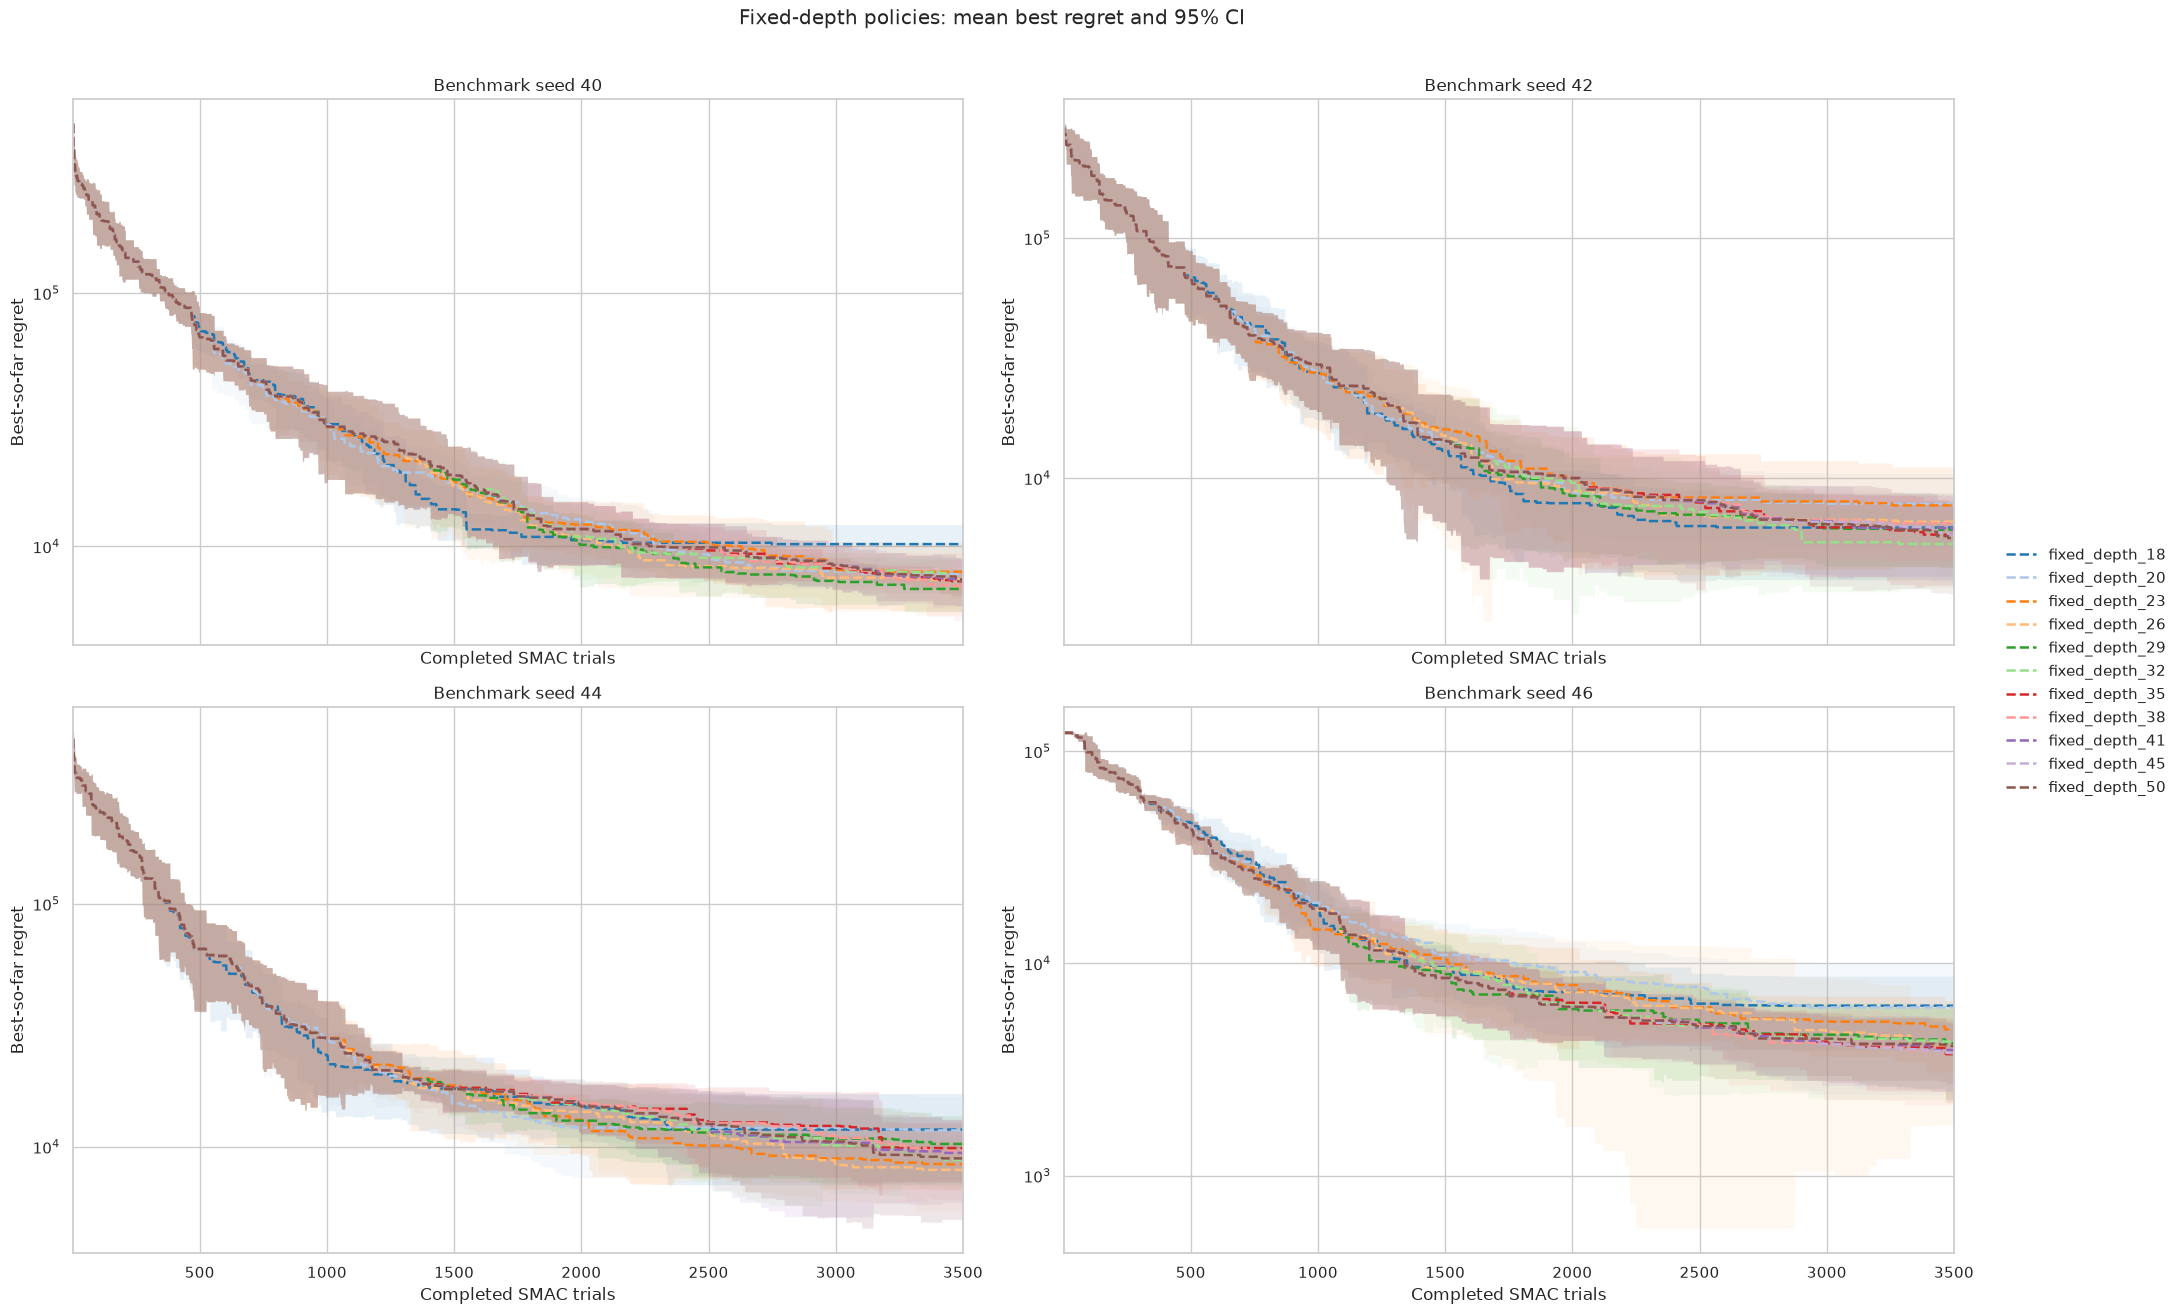

In [21]:
plot_confidence_trajectories(FIXED_POLICIES, 'Fixed-depth policies: mean best regret and 95% CI')

### 2. Adaptive policies

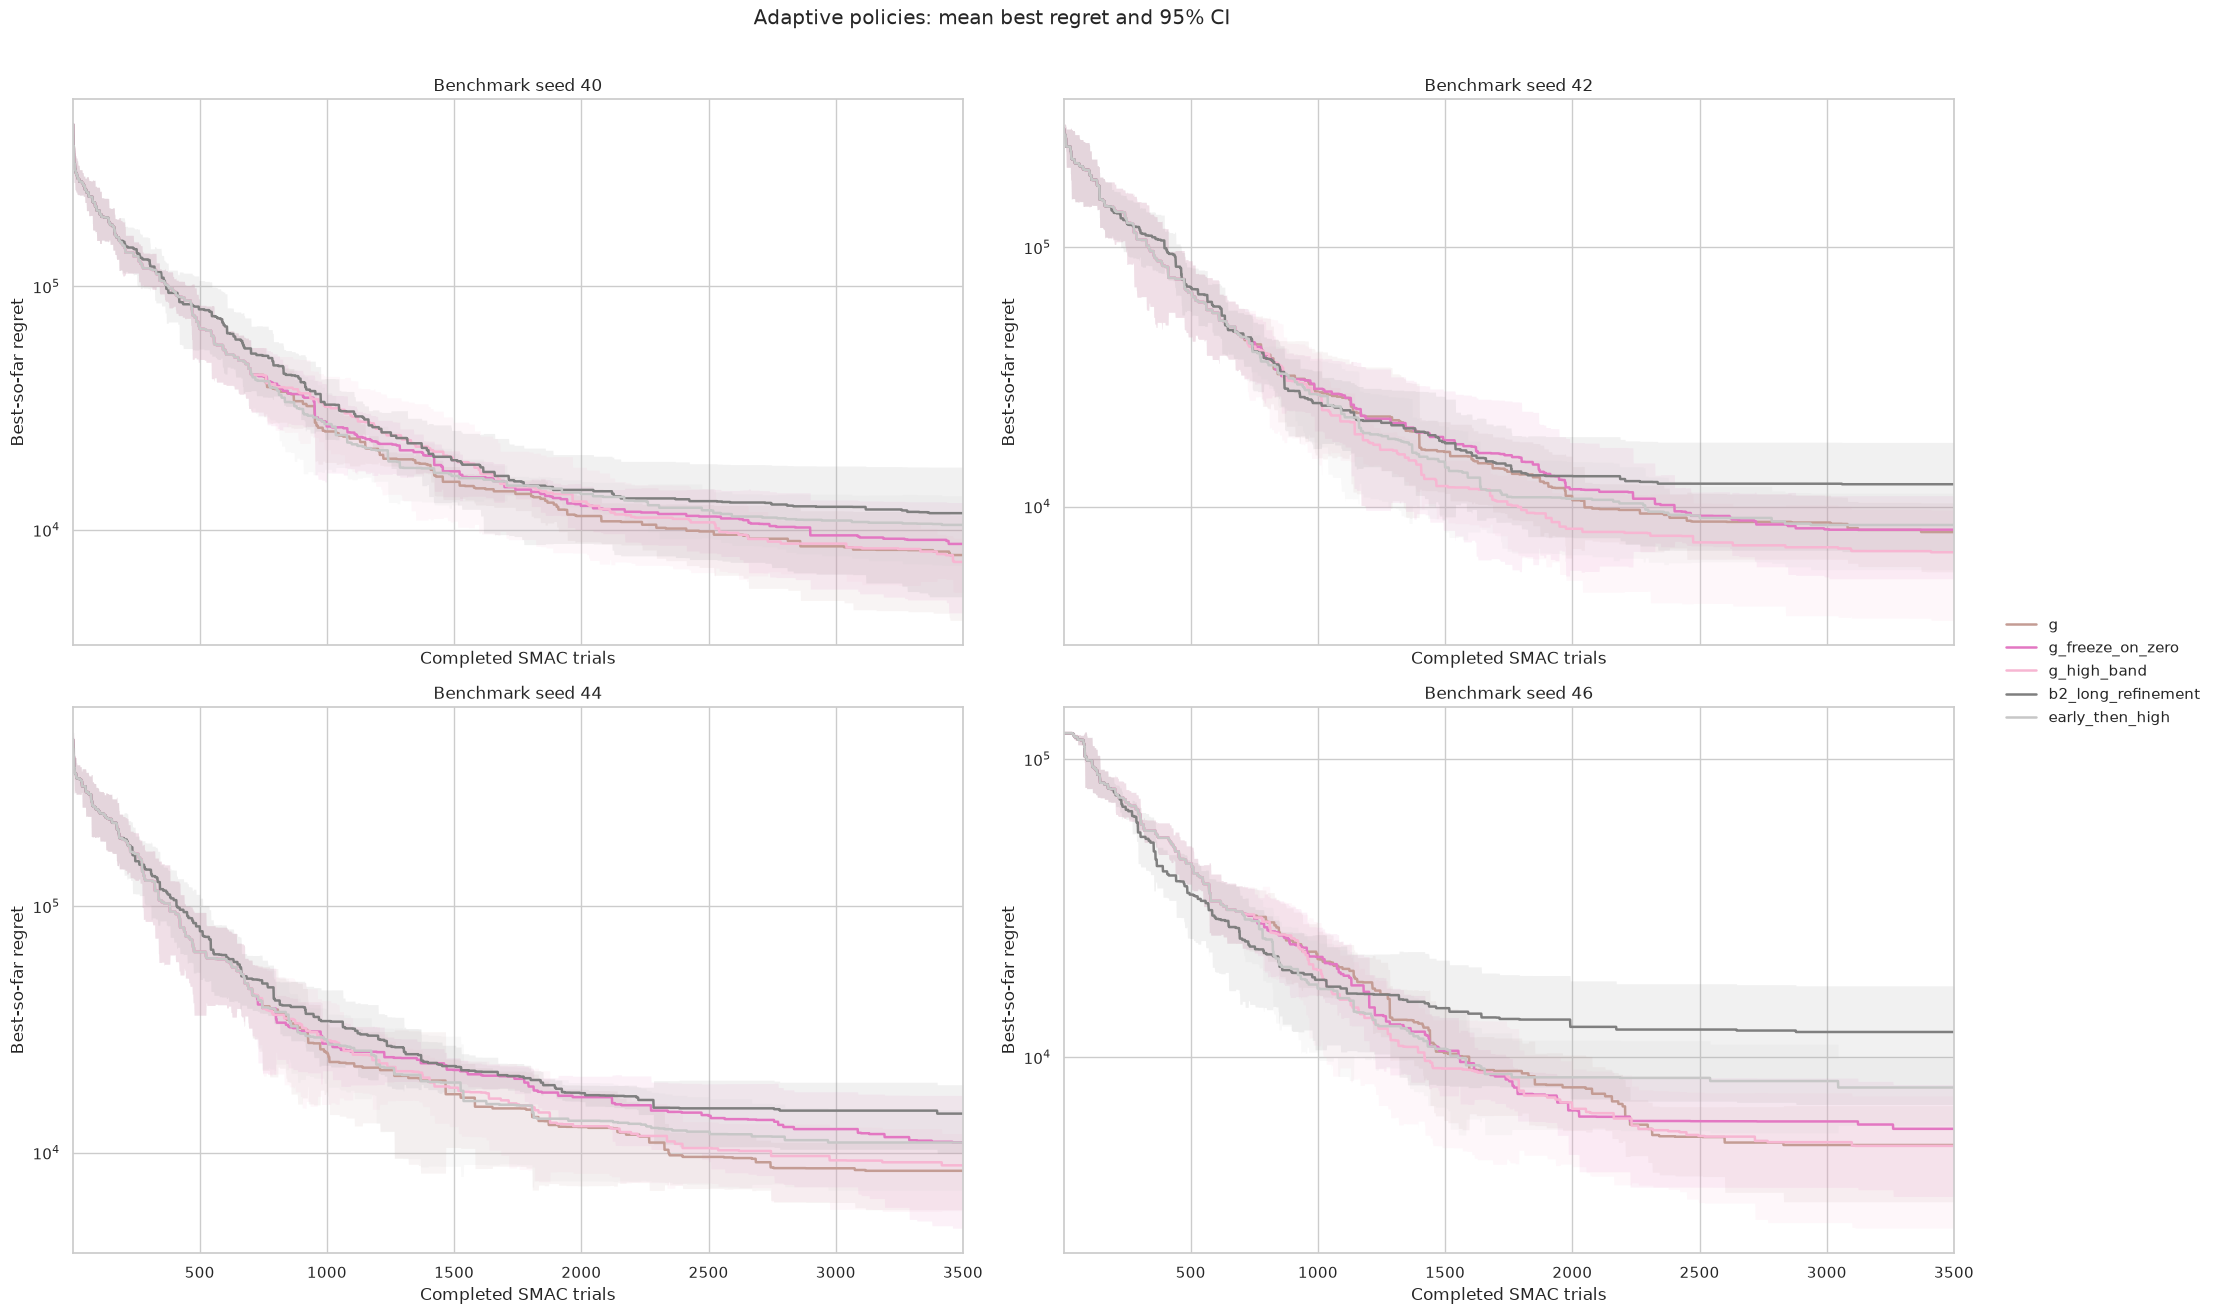

In [22]:
plot_confidence_trajectories(ADAPTIVE_POLICIES, 'Adaptive policies: mean best regret and 95% CI')

### 3. All policies

Dashed lines are fixed-depth controls; solid lines are adaptive policies.

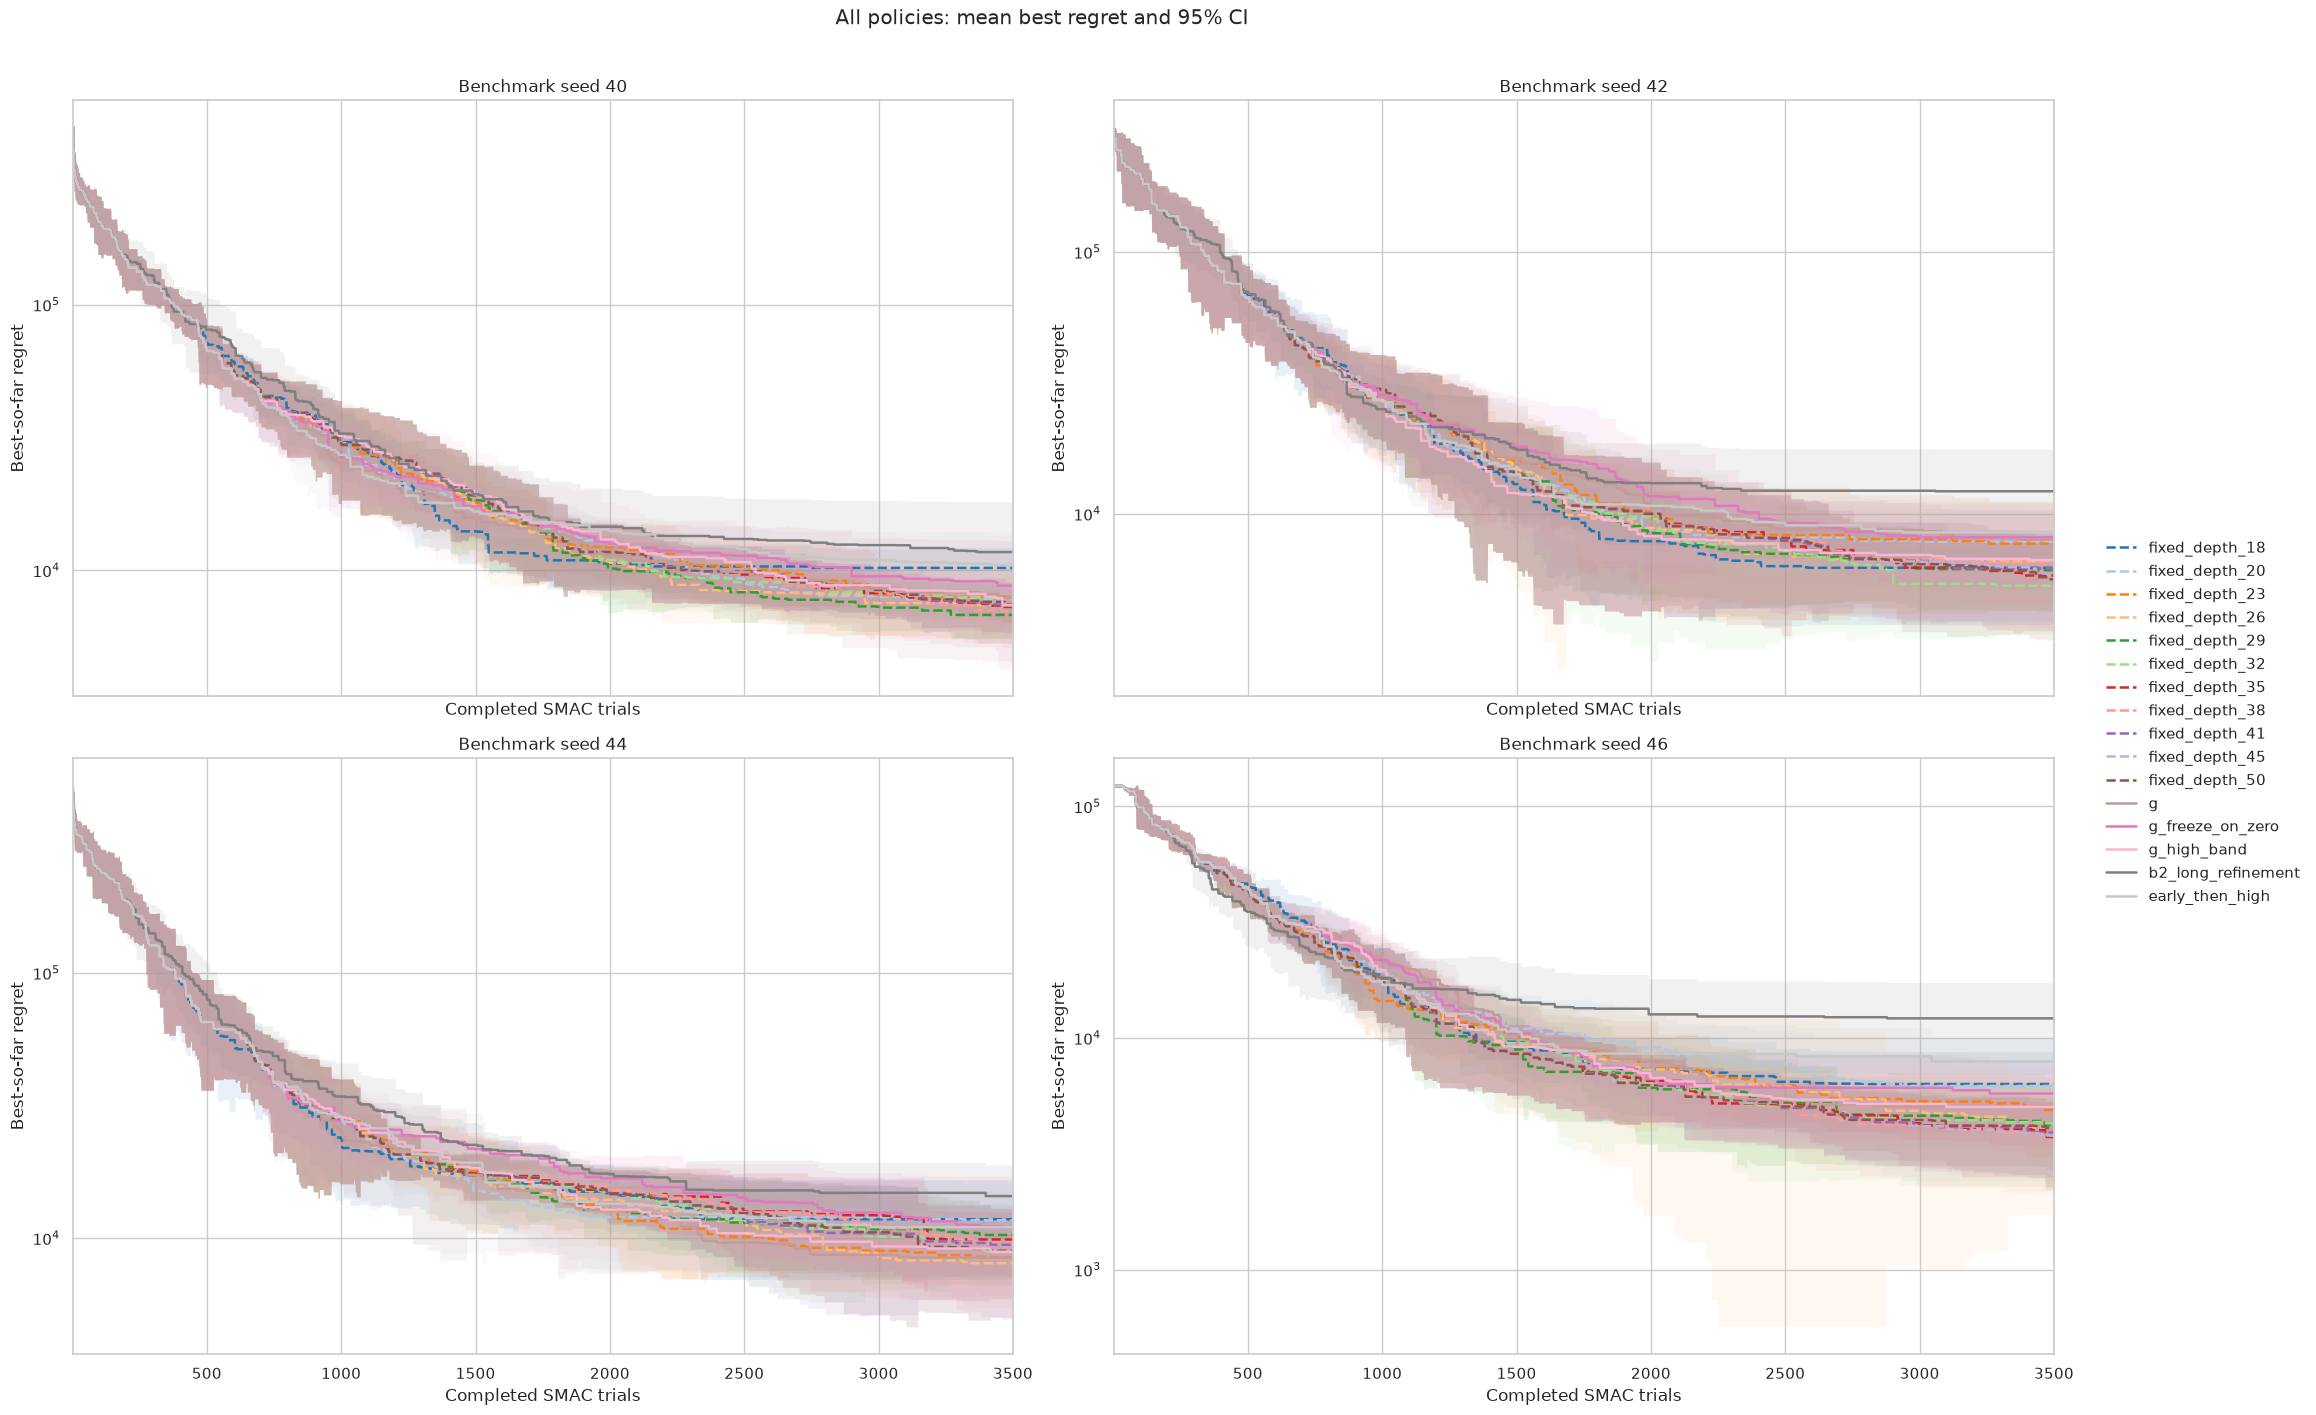

In [23]:
plot_confidence_trajectories(POLICIES, 'All policies: mean best regret and 95% CI', figure_size=(21, 14))

## 4. Best-so-far regret boxplots every 500 trials

Each box contains the six SMAC-seed values for one policy. There is one seven-panel figure per benchmark landscape.

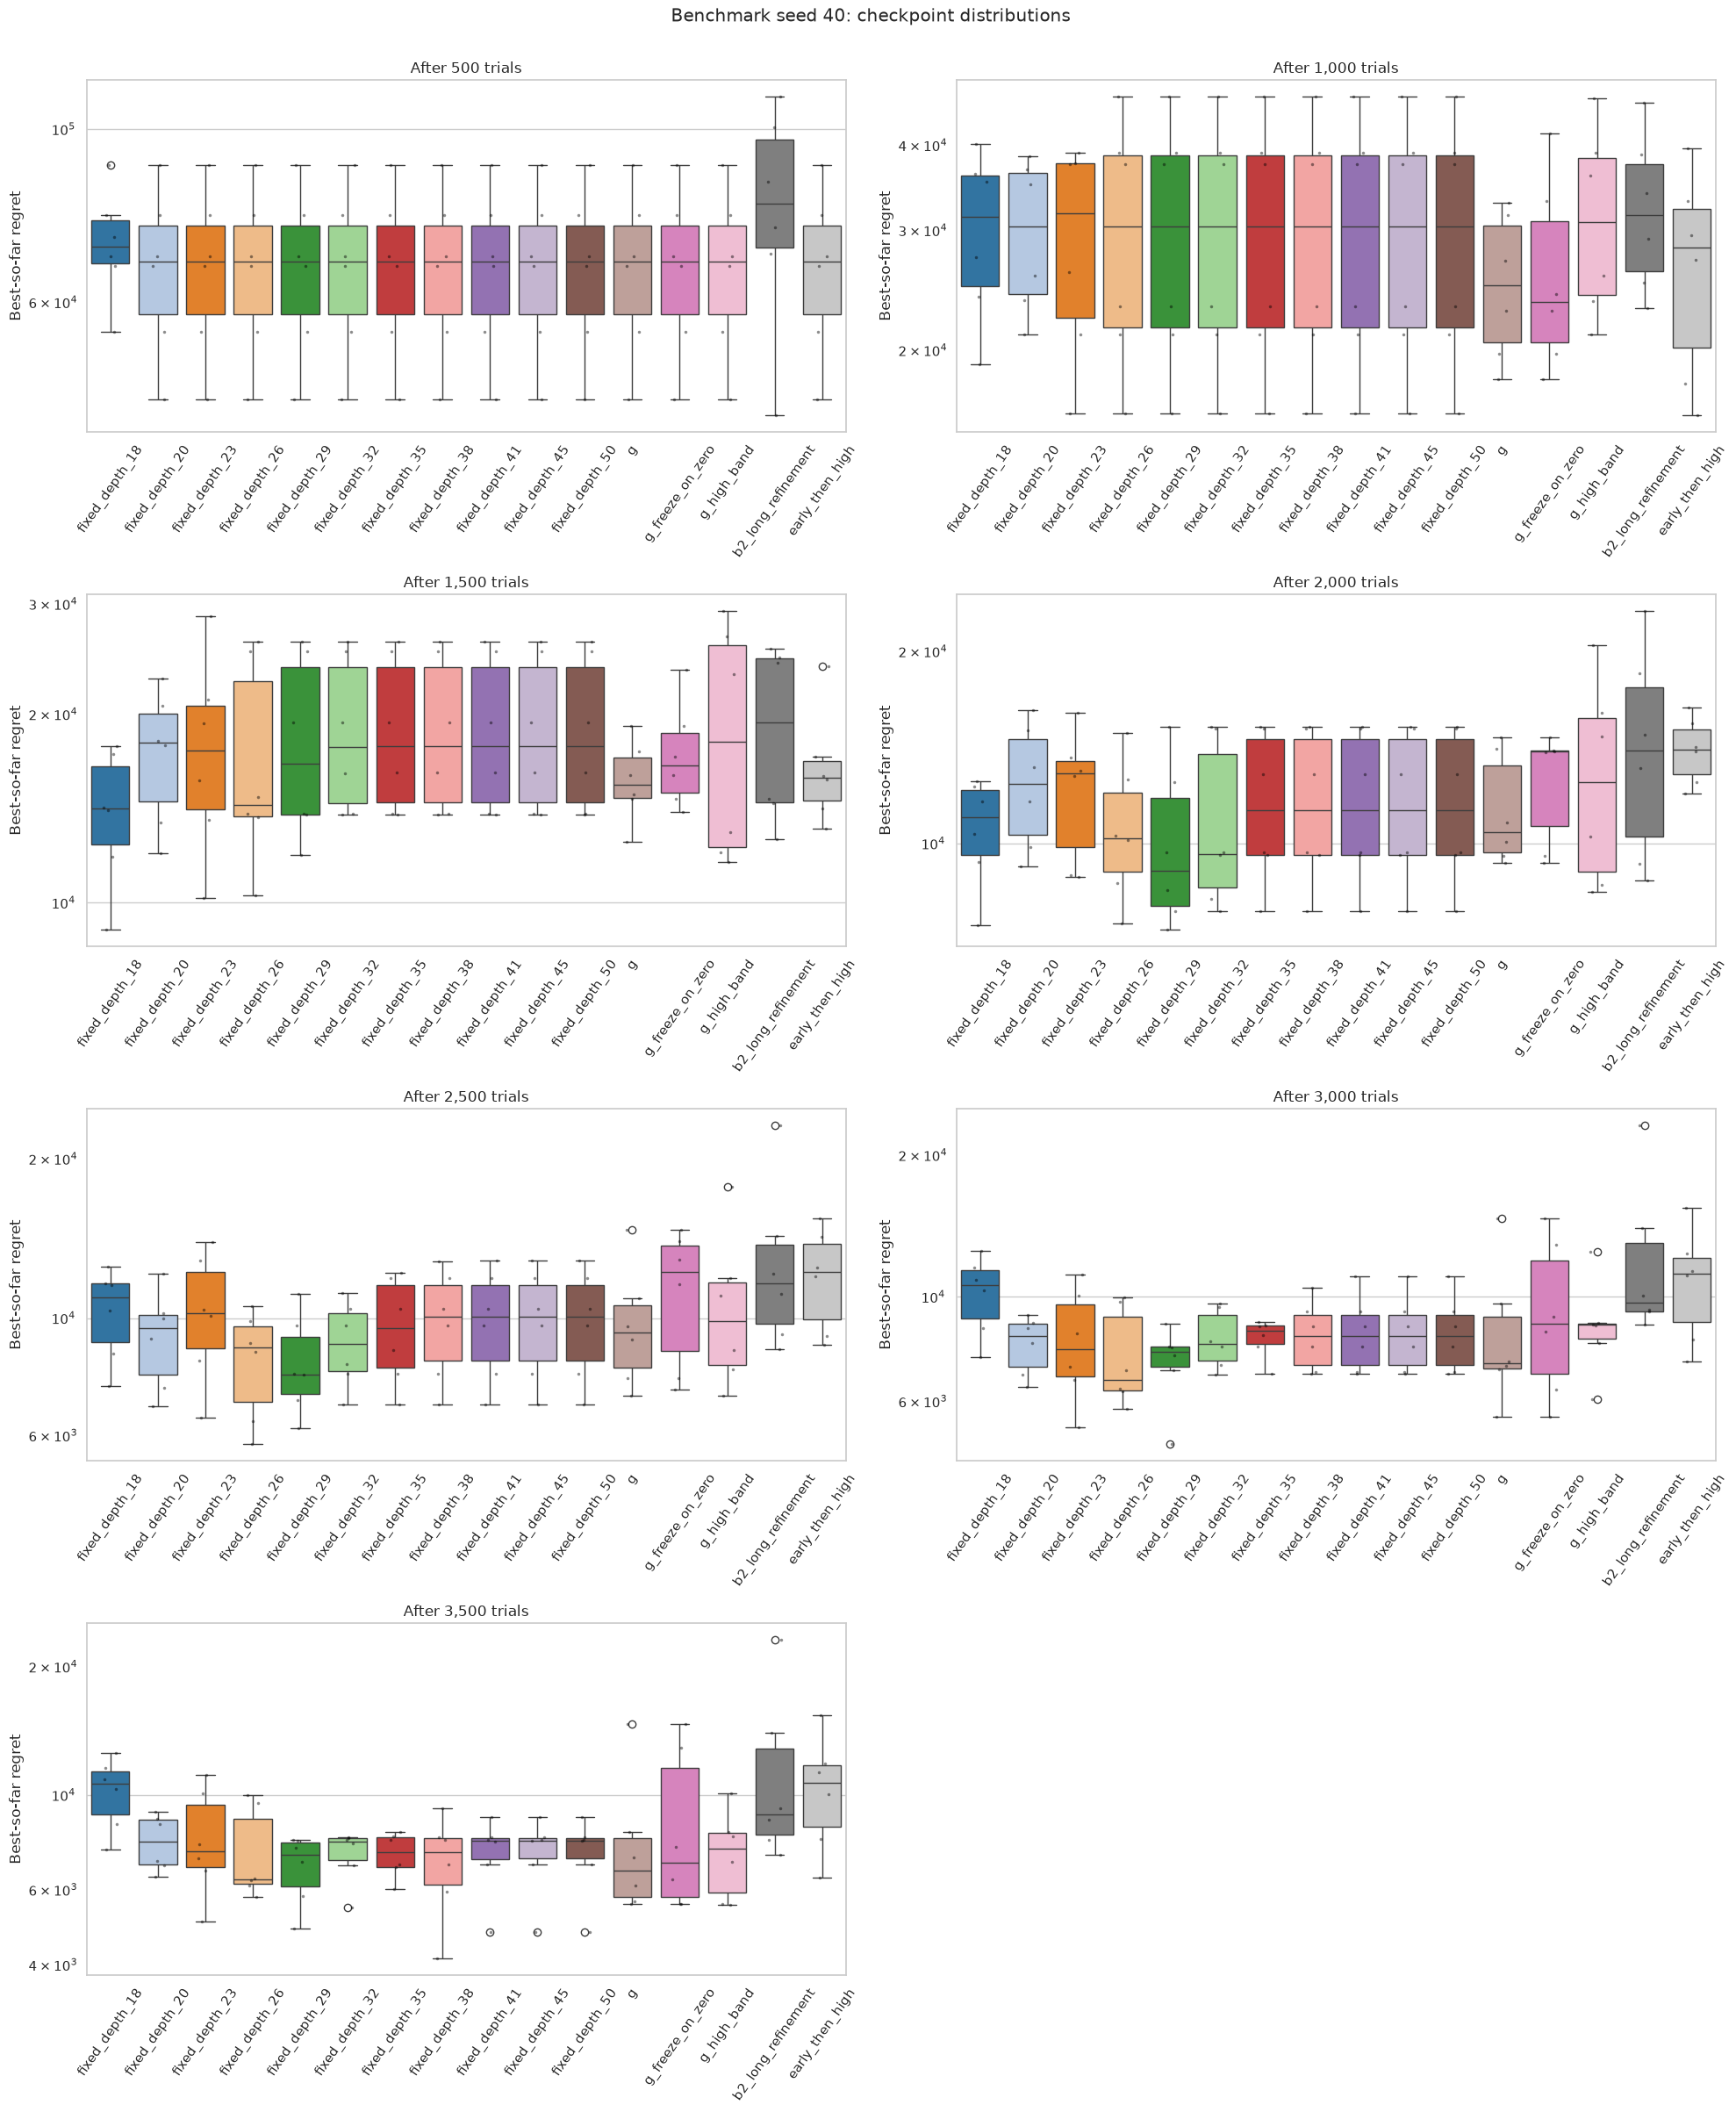

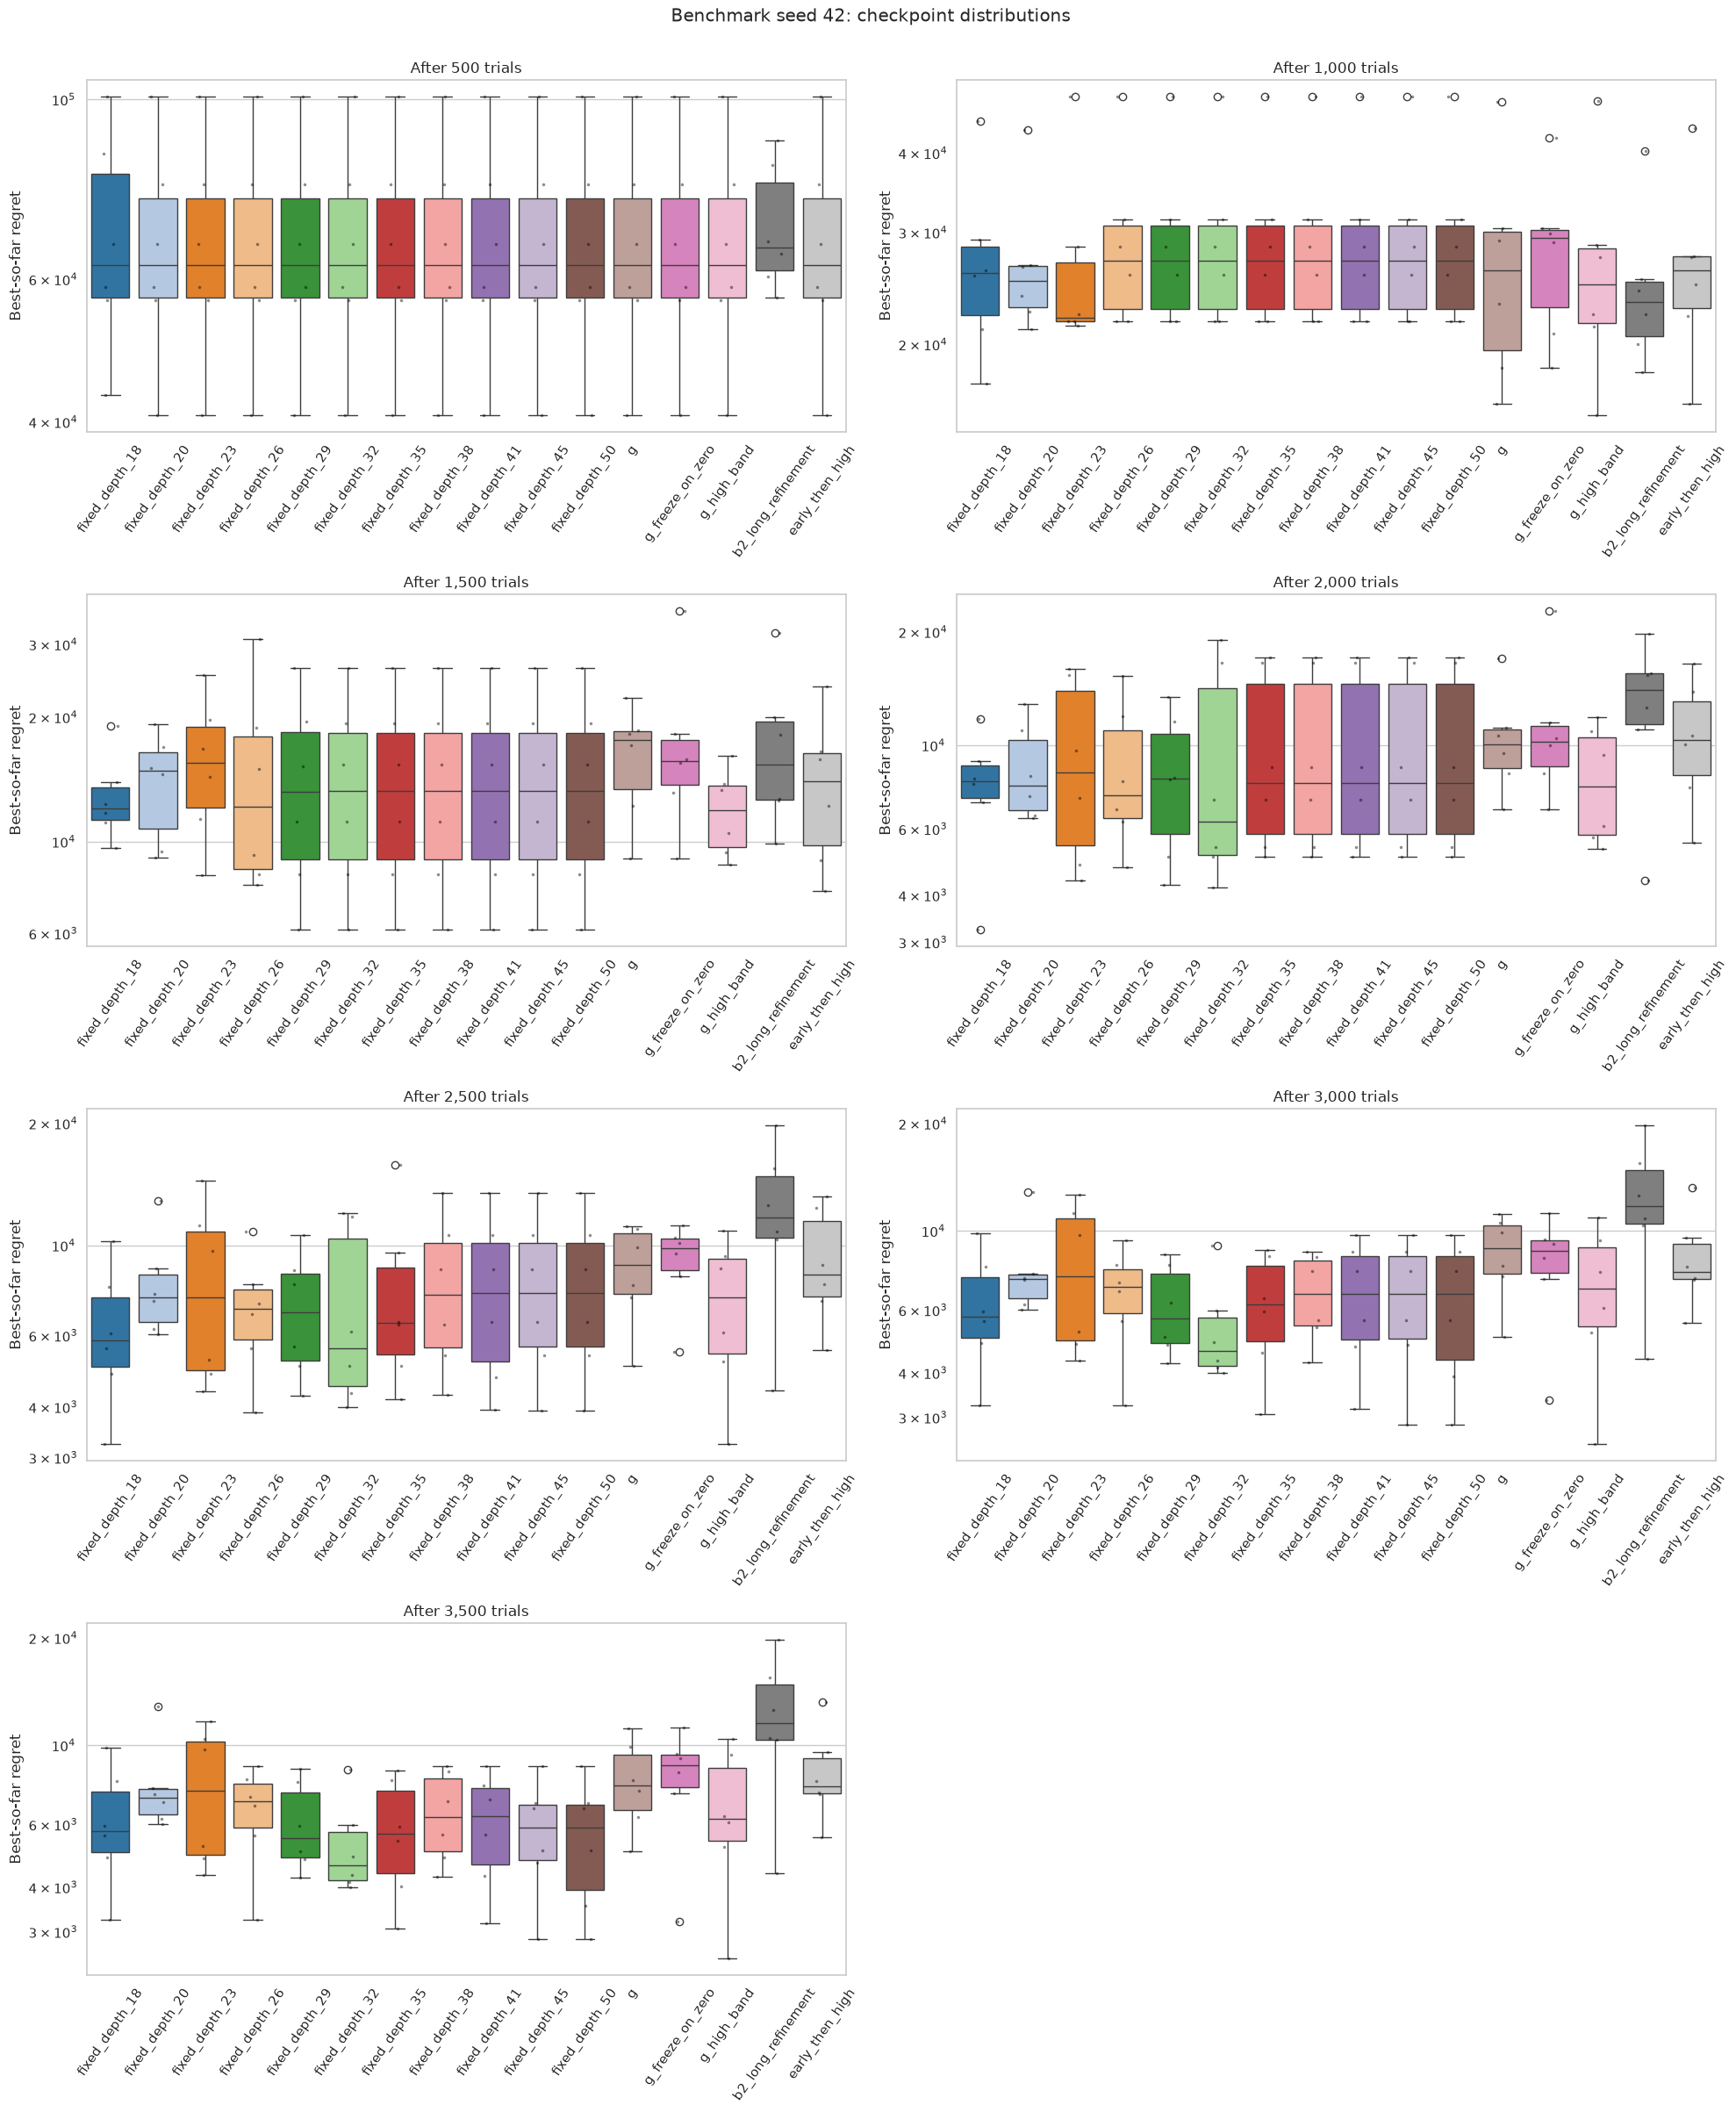

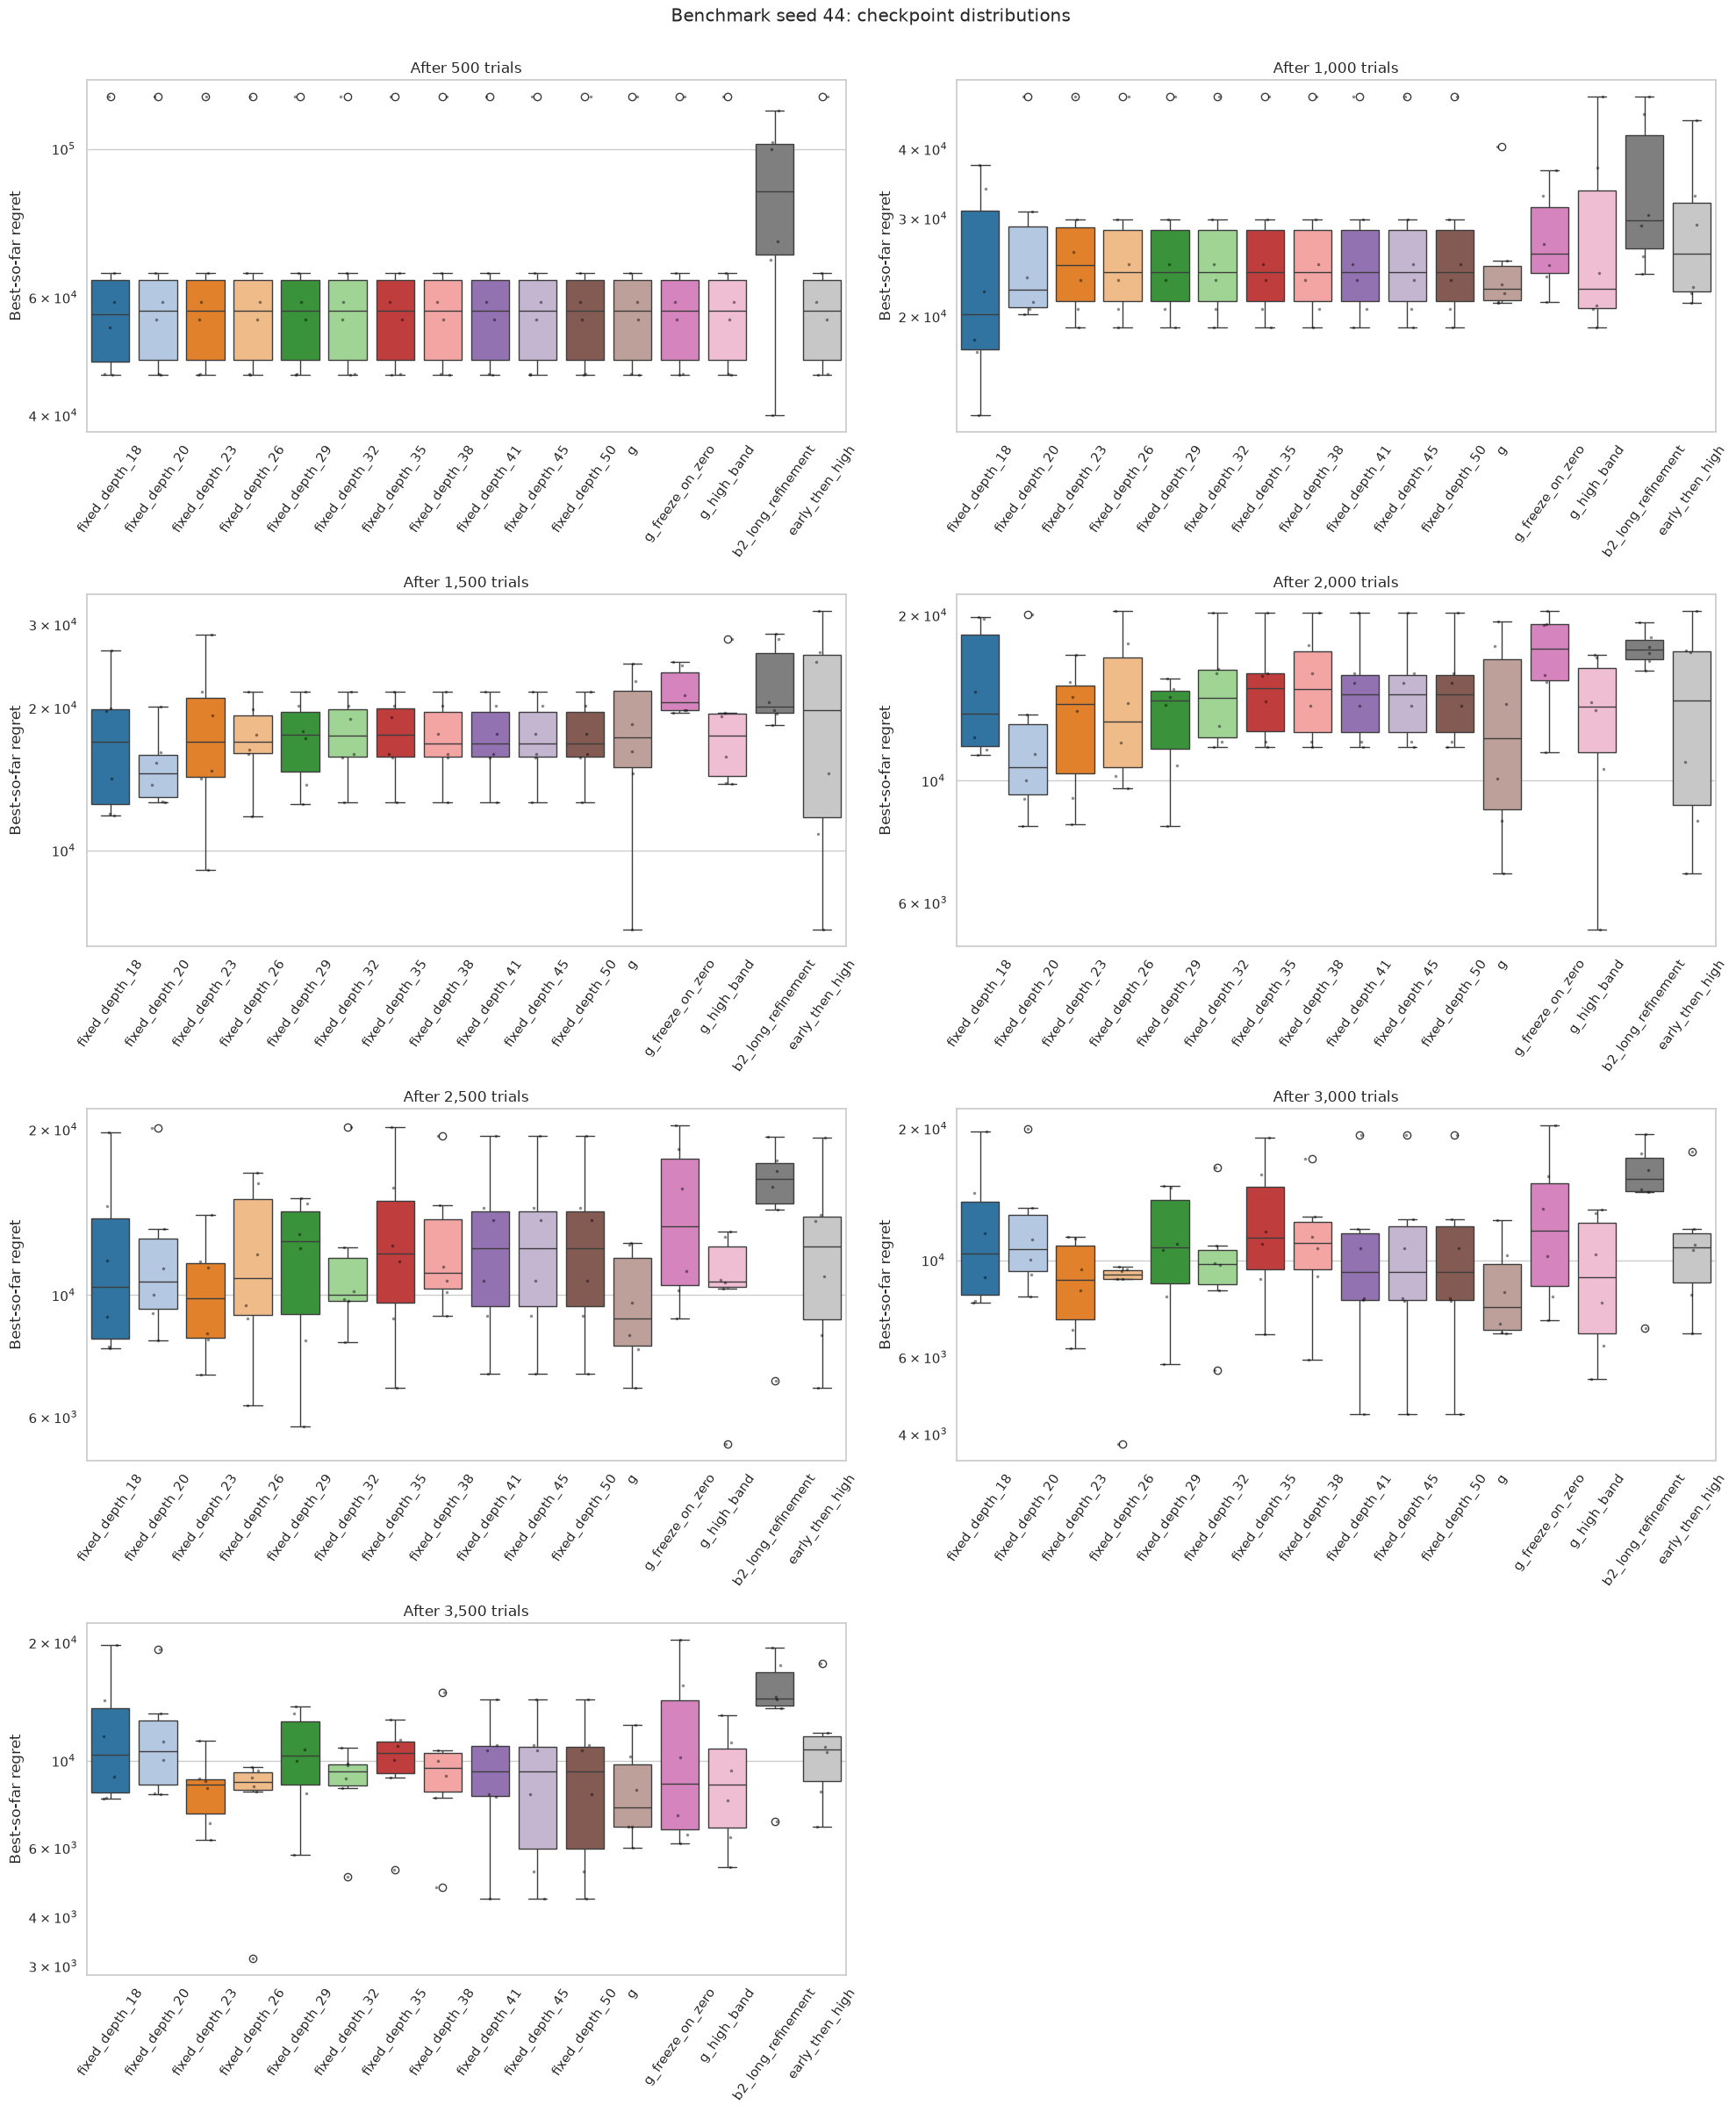

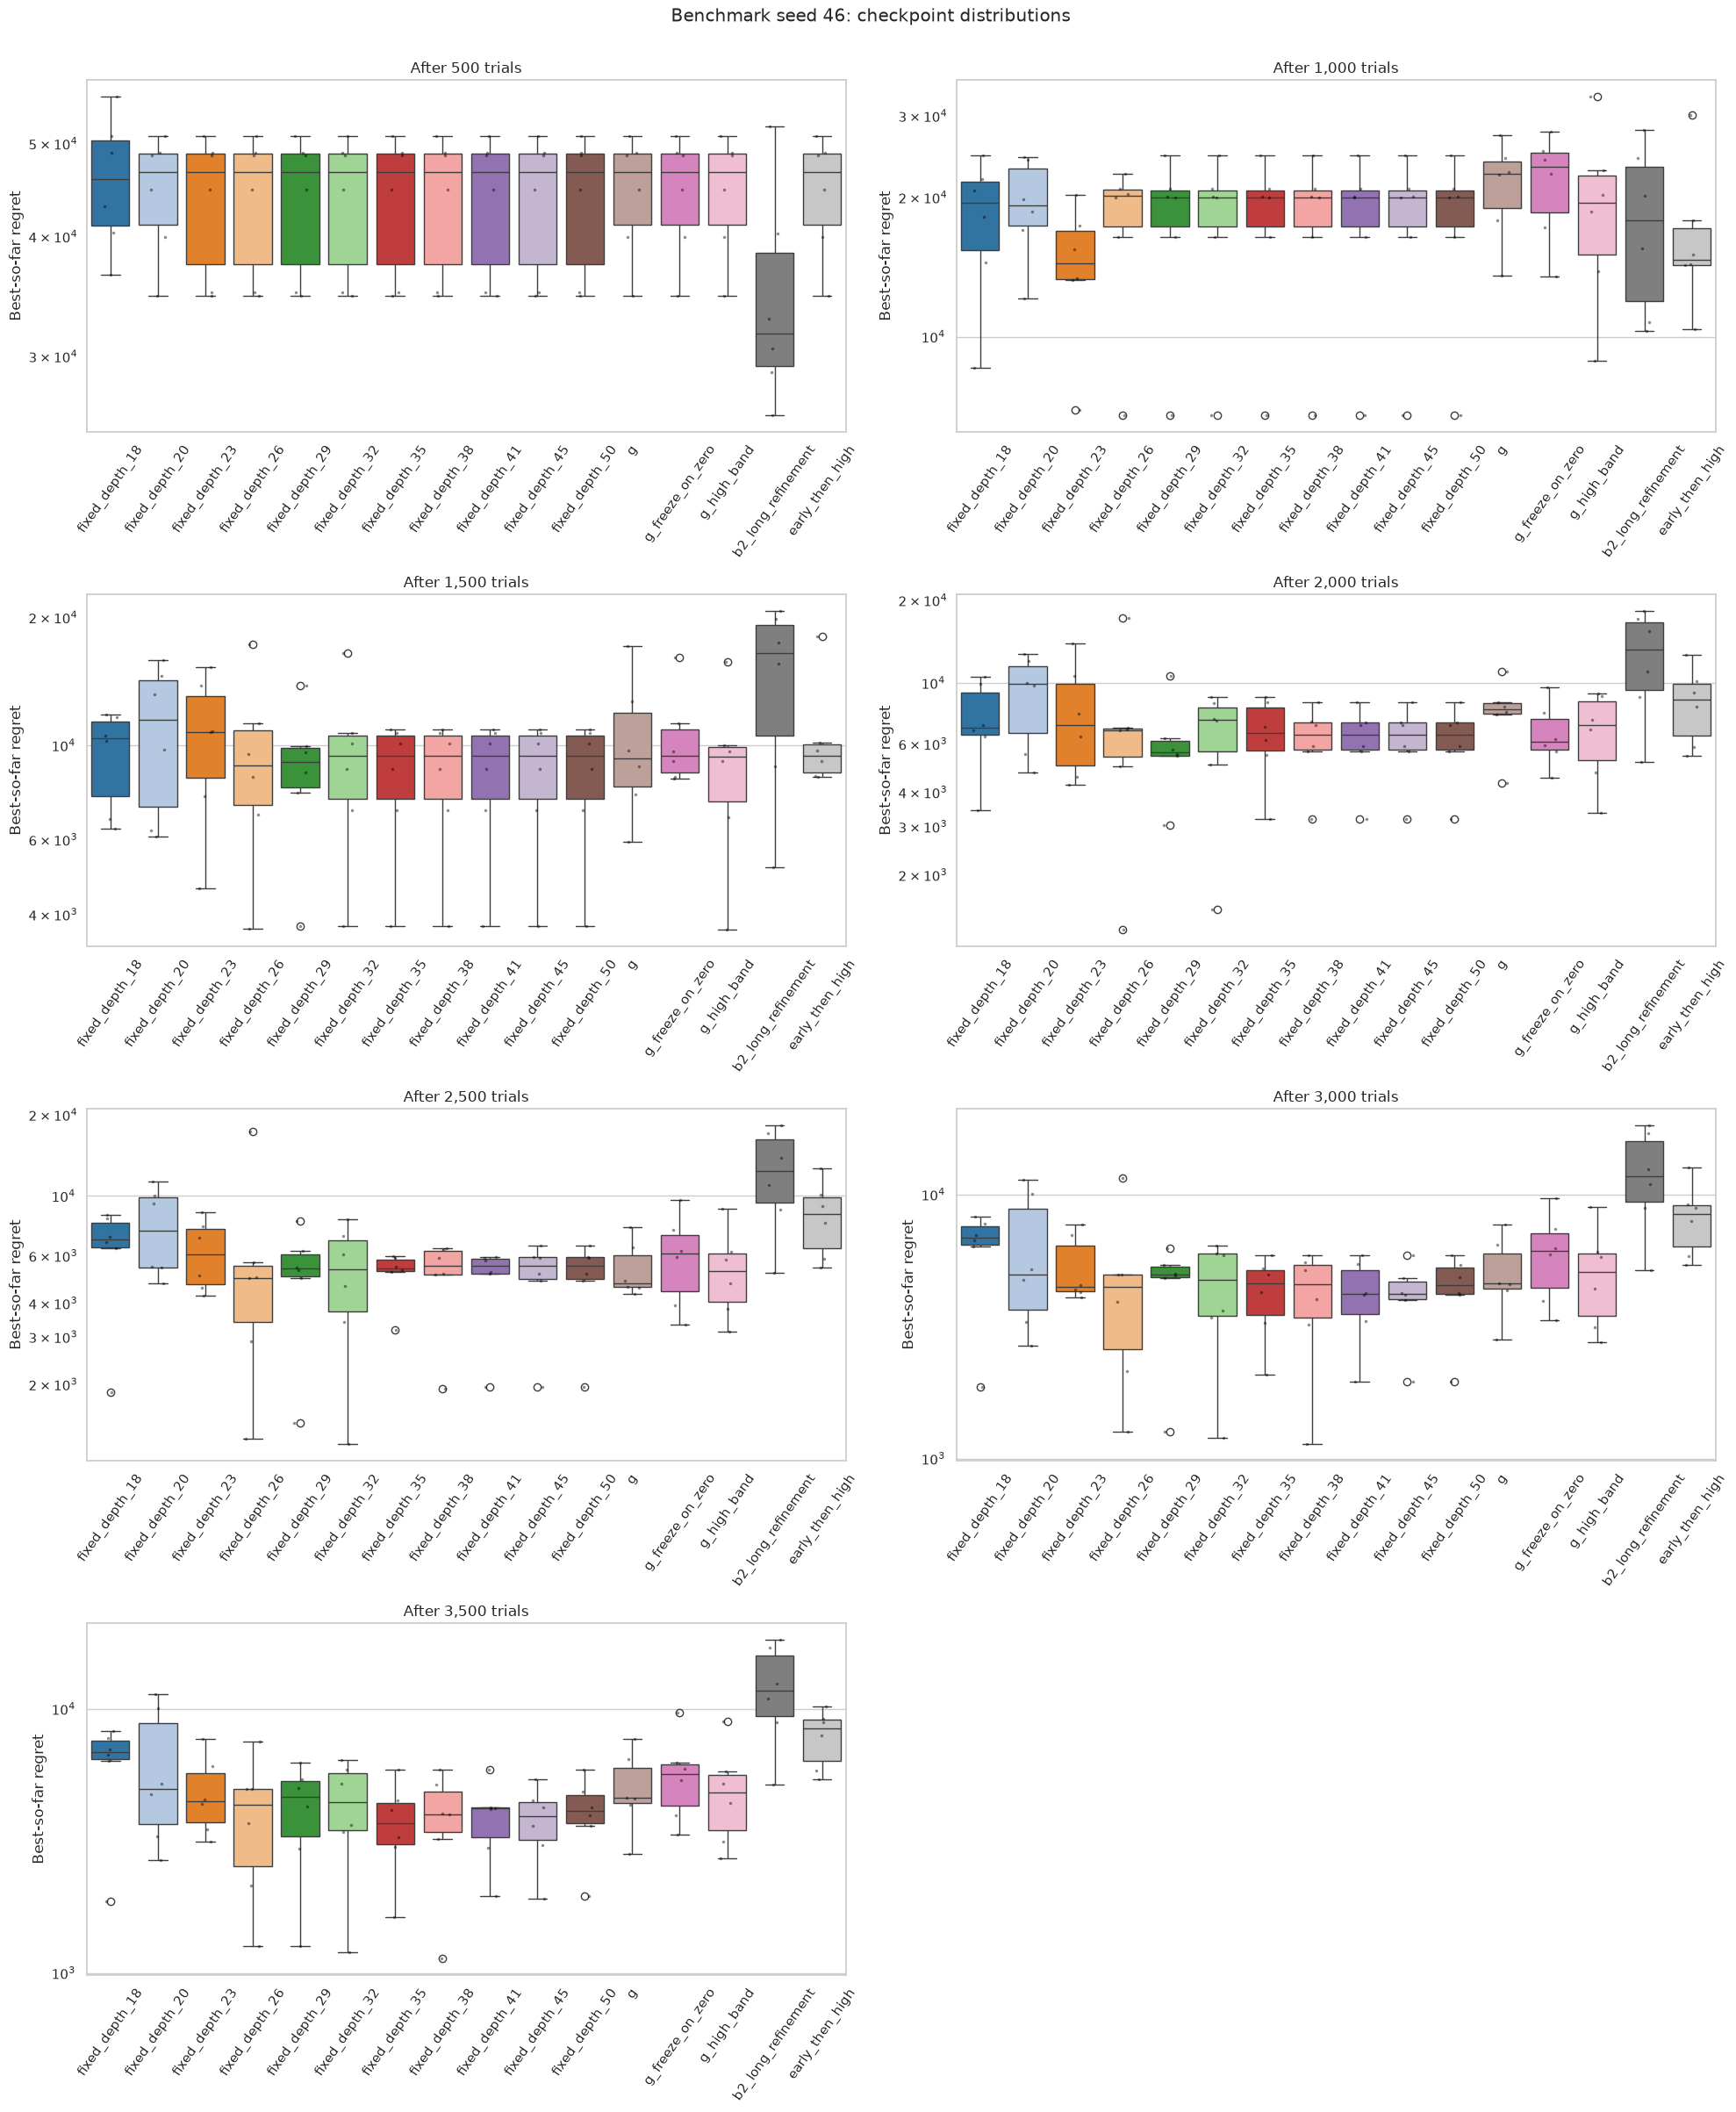

In [24]:
for benchmark_seed in BENCHMARK_SEEDS:
    fig, axes = plt.subplots(4, 2, figsize=(20, 24), sharey=False)
    for axis, checkpoint in zip(axes.ravel(), CHECKPOINTS):
        values = checkpoint_data.query(
            'benchmark_seed == @benchmark_seed and iteration == @checkpoint'
        )
        sns.boxplot(
            data=values, x='policy', y='plot_regret', order=POLICIES,
            hue='policy', palette=colors, dodge=False, legend=False,
            showfliers=True, ax=axis,
        )
        sns.stripplot(
            data=values, x='policy', y='plot_regret', order=POLICIES,
            color='black', alpha=0.45, size=2.5, jitter=0.15, ax=axis,
        )
        axis.set_yscale('log')
        axis.set_title(f'After {checkpoint:,} trials')
        axis.set_xlabel('')
        axis.set_ylabel('Best-so-far regret')
        axis.tick_params(axis='x', rotation=55)
    axes.ravel()[-1].axis('off')
    fig.suptitle(f'Benchmark seed {benchmark_seed}: checkpoint distributions', y=1.002)
    fig.tight_layout()
    plt.show()

## 5. Final policy ranking within each benchmark

Rank 1 has the lowest mean final best regret over the six SMAC seeds. Exact mean ties share a rank; the table order then follows the declared policy order.

In [25]:
final_summary = (
    final_data.groupby(['benchmark_seed', 'policy', 'policy_family'], as_index=False)
    .agg(
        mean_final_regret=('final_best_regret', 'mean'),
        median_final_regret=('final_best_regret', 'median'),
        std_final_regret=('final_best_regret', 'std'),
        n=('smac_seed', 'size'),
    )
)
final_summary['ci95'] = (
    t.ppf(0.975, final_summary['n'] - 1)
    * final_summary['std_final_regret'] / np.sqrt(final_summary['n'])
)
final_summary['rank'] = (
    final_summary.groupby('benchmark_seed')['mean_final_regret']
    .rank(method='min', ascending=True).astype(int)
)
final_summary['policy_order'] = final_summary['policy'].map(POLICY_ORDER)
for benchmark_seed in BENCHMARK_SEEDS:
    table = (
        final_summary.query('benchmark_seed == @benchmark_seed')
        .sort_values(['rank', 'policy_order'])
        [['rank', 'policy', 'policy_family', 'mean_final_regret', 'ci95',
          'median_final_regret', 'std_final_regret', 'n']]
    )
    print(f'Benchmark seed {benchmark_seed}')
    display(table.style.format({
        'mean_final_regret': '{:.6g}', 'ci95': '{:.3g}',
        'median_final_regret': '{:.6g}', 'std_final_regret': '{:.3g}',
    }))

Benchmark seed 40


,rank,policy,policy_family,mean_final_regret,ci95,median_final_regret,std_final_regret,n
6,1,fixed_depth_29,fixed,6799.26,1.27e+03,7244.16,1.21e+03,6
9,2,fixed_depth_38,fixed,7001.99,1.89e+03,7348.79,1.8e+03,6
8,3,fixed_depth_35,fixed,7276.62,896,7348.79,853,6
7,4,fixed_depth_32,fixed,7285.58,1.04e+03,7762.16,988,6
10,5,fixed_depth_41,fixed,7345.37,1.48e+03,7806,1.41e+03,6
11,6,fixed_depth_45,fixed,7354.86,1.49e+03,7826.83,1.42e+03,6
12,6,fixed_depth_50,fixed,7354.86,1.49e+03,7826.83,1.42e+03,6
5,8,fixed_depth_26,fixed,7362.37,1.99e+03,6338.9,1.9e+03,6
15,9,g_high_band,adaptive,7387.9,1.84e+03,7471.16,1.75e+03,6
3,10,fixed_depth_20,fixed,7794.67,1.23e+03,7782.03,1.17e+03,6


Benchmark seed 42


,rank,policy,policy_family,mean_final_regret,ci95,median_final_regret,std_final_regret,n
23,1,fixed_depth_32,fixed,5316.22,1.83e+03,4609.51,1.75e+03,6
28,2,fixed_depth_50,fixed,5627.76,2.33e+03,5865.13,2.22e+03,6
24,3,fixed_depth_35,fixed,5816.25,2.24e+03,5663.22,2.13e+03,6
27,4,fixed_depth_45,fixed,5816.64,2.15e+03,5865.13,2.05e+03,6
22,5,fixed_depth_29,fixed,6091.41,1.86e+03,5502.59,1.77e+03,6
26,6,fixed_depth_41,fixed,6106.86,2.23e+03,6336.71,2.13e+03,6
18,7,fixed_depth_18,fixed,6222.88,2.45e+03,5759.81,2.33e+03,6
25,8,fixed_depth_38,fixed,6484.31,1.96e+03,6293.06,1.87e+03,6
21,9,fixed_depth_26,fixed,6583.94,2.06e+03,6975.23,1.96e+03,6
31,10,g_high_band,adaptive,6664.62,3.03e+03,6216.07,2.88e+03,6


Benchmark seed 44


,rank,policy,policy_family,mean_final_regret,ci95,median_final_regret,std_final_regret,n
37,1,fixed_depth_26,fixed,8040.8,2.57e+03,8836.52,2.45e+03,6
45,2,g,adaptive,8443.42,2.57e+03,7618.68,2.45e+03,6
36,3,fixed_depth_23,fixed,8473.58,1.83e+03,8698.48,1.74e+03,6
39,4,fixed_depth_32,fixed,8831.39,2.1e+03,9388.93,2e+03,6
47,5,g_high_band,adaptive,8884.91,3.06e+03,8682.56,2.92e+03,6
43,6,fixed_depth_45,fixed,8966.45,3.94e+03,9416.18,3.76e+03,6
44,6,fixed_depth_50,fixed,8966.45,3.94e+03,9416.18,3.76e+03,6
42,8,fixed_depth_41,fixed,9444.95,3.51e+03,9416.18,3.35e+03,6
41,9,fixed_depth_38,fixed,9591.66,3.51e+03,9584.73,3.34e+03,6
40,10,fixed_depth_35,fixed,9885.31,2.69e+03,10473.1,2.57e+03,6


Benchmark seed 46


,rank,policy,policy_family,mean_final_regret,ci95,median_final_regret,std_final_regret,n
56,1,fixed_depth_35,fixed,3738.34,1.53e+03,3700.96,1.46e+03,6
59,2,fixed_depth_45,fixed,3785.15,1.28e+03,3919.87,1.22e+03,6
57,3,fixed_depth_38,fixed,3900.94,1.74e+03,3987.73,1.66e+03,6
58,4,fixed_depth_41,fixed,3909.12,1.4e+03,4196.11,1.34e+03,6
60,5,fixed_depth_50,fixed,4085.54,1.39e+03,4098.61,1.32e+03,6
53,6,fixed_depth_26,fixed,4099.42,2.36e+03,4338.31,2.25e+03,6
54,7,fixed_depth_29,fixed,4198.88,1.91e+03,4638.32,1.82e+03,6
55,8,fixed_depth_32,fixed,4288.17,2.02e+03,4419.58,1.93e+03,6
52,9,fixed_depth_23,fixed,4889.87,1.8e+03,4459.21,1.71e+03,6
63,10,g_high_band,adaptive,5041.97,2.37e+03,4813.95,2.26e+03,6


## 6. Ranking across benchmarks

The primary cross-benchmark criterion is mean within-benchmark rank, which gives each landscape equal weight. `pooled_mean_final_regret` is also shown for scale, but it can overweight landscapes with larger regret values.

In [26]:
across_benchmarks = (
    final_summary.groupby(['policy', 'policy_family'], as_index=False)
    .agg(
        mean_benchmark_rank=('rank', 'mean'),
        median_benchmark_rank=('rank', 'median'),
        best_benchmark_rank=('rank', 'min'),
        worst_benchmark_rank=('rank', 'max'),
        benchmark_wins=('rank', lambda values: int((values == 1).sum())),
        mean_of_benchmark_means=('mean_final_regret', 'mean'),
    )
)
pooled = final_data.groupby('policy')['final_best_regret'].mean().rename('pooled_mean_final_regret')
across_benchmarks = across_benchmarks.join(pooled, on='policy')
across_benchmarks['policy_order'] = across_benchmarks['policy'].map(POLICY_ORDER)
across_benchmarks = across_benchmarks.sort_values(
    ['mean_benchmark_rank', 'pooled_mean_final_regret', 'policy_order']
).reset_index(drop=True)
across_benchmarks.insert(0, 'overall_rank', np.arange(1, len(across_benchmarks) + 1))
display(across_benchmarks.drop(columns='policy_order').style.format({
    'mean_benchmark_rank': '{:.2f}', 'median_benchmark_rank': '{:.1f}',
    'mean_of_benchmark_means': '{:.6g}', 'pooled_mean_final_regret': '{:.6g}',
}))

,overall_rank,policy,policy_family,mean_benchmark_rank,median_benchmark_rank,best_benchmark_rank,worst_benchmark_rank,benchmark_wins,mean_of_benchmark_means,pooled_mean_final_regret
0,1,fixed_depth_32,fixed,4.25,4.0,1,8,1,6430.34,6430.34
1,2,fixed_depth_35,fixed,4.25,3.0,1,10,1,6679.13,6679.13
2,3,fixed_depth_45,fixed,4.50,5.0,2,6,0,6480.78,6480.78
3,4,fixed_depth_50,fixed,4.75,5.5,2,6,0,6508.65,6508.65
4,5,fixed_depth_38,fixed,5.50,5.5,2,9,0,6744.72,6744.72
5,6,fixed_depth_41,fixed,5.75,5.5,4,8,0,6701.58,6701.58
6,7,fixed_depth_26,fixed,6.00,7.0,1,9,1,6521.63,6521.63
7,8,fixed_depth_29,fixed,6.00,6.0,1,11,1,6842.52,6842.52
8,9,g_high_band,adaptive,8.50,9.5,5,10,0,6994.85,6994.85
9,10,fixed_depth_23,fixed,8.75,10.0,3,12,0,7253.01,7253.01


## 7. Leave-one-benchmark-out policy selection

For each held-out benchmark, the selected policy is the one with the lowest pooled mean final best regret over all 18 runs from the other three benchmarks. The selected policy is then compared against all 16 policies using only the six held-out runs. This selection never uses the held-out landscape.

In [27]:
loo_rows = []
loo_tables = {}
for held_out in BENCHMARK_SEEDS:
    training = (
        final_data.query('benchmark_seed != @held_out')
        .groupby('policy', as_index=False)
        .agg(training_mean_final_regret=('final_best_regret', 'mean'), training_runs=('final_best_regret', 'size'))
    )
    training['policy_order'] = training['policy'].map(POLICY_ORDER)
    training['training_rank'] = training['training_mean_final_regret'].rank(method='min', ascending=True).astype(int)
    training = training.sort_values(['training_mean_final_regret', 'policy_order'])
    selected_policy = training.iloc[0]['policy']

    held = (
        final_summary.query('benchmark_seed == @held_out')
        .merge(training[['policy', 'training_mean_final_regret', 'training_rank']], on='policy')
        .sort_values(['rank', 'policy_order'])
        .copy()
    )
    held['selected_by_loo'] = held['policy'].eq(selected_policy)
    selected = held.query('policy == @selected_policy').iloc[0]
    oracle = held.iloc[0]
    loo_rows.append({
        'held_out_benchmark': held_out,
        'selected_policy': selected_policy,
        'training_mean_final_regret': float(selected['training_mean_final_regret']),
        'heldout_mean_final_regret': float(selected['mean_final_regret']),
        'heldout_rank': int(selected['rank']),
        'heldout_oracle_policy': oracle['policy'],
        'heldout_oracle_mean_regret': float(oracle['mean_final_regret']),
        'regret_gap_to_heldout_oracle': float(selected['mean_final_regret'] - oracle['mean_final_regret']),
    })
    loo_tables[held_out] = held

loo_summary = pd.DataFrame(loo_rows)
display(loo_summary.style.format({
    'training_mean_final_regret': '{:.6g}',
    'heldout_mean_final_regret': '{:.6g}',
    'heldout_oracle_mean_regret': '{:.6g}',
    'regret_gap_to_heldout_oracle': '{:.6g}',
}))
for held_out, table in loo_tables.items():
    print(f'Held-out benchmark seed {held_out}')
    display(table[[
        'rank', 'policy', 'selected_by_loo', 'mean_final_regret', 'ci95',
        'training_rank', 'training_mean_final_regret',
    ]].style.format({
        'mean_final_regret': '{:.6g}', 'ci95': '{:.3g}',
        'training_mean_final_regret': '{:.6g}',
    }))

,held_out_benchmark,selected_policy,training_mean_final_regret,heldout_mean_final_regret,heldout_rank,heldout_oracle_policy,heldout_oracle_mean_regret,regret_gap_to_heldout_oracle
0,40,fixed_depth_32,6145.26,7285.58,4,fixed_depth_29,6799.26,486.316
1,42,fixed_depth_26,6500.86,6583.94,9,fixed_depth_32,5316.22,1267.71
2,44,fixed_depth_35,5610.4,9885.31,10,fixed_depth_26,8040.8,1844.51
3,46,fixed_depth_32,7144.4,4288.17,8,fixed_depth_35,3738.34,549.832


Held-out benchmark seed 40


,rank,policy,selected_by_loo,mean_final_regret,ci95,training_rank,training_mean_final_regret
6,1,fixed_depth_29,False,6799.26,1.27e+03,8,6856.93
9,2,fixed_depth_38,False,7001.99,1.89e+03,7,6658.97
8,3,fixed_depth_35,False,7276.62,896,5,6479.97
7,4,fixed_depth_32,True,7285.58,1.04e+03,1,6145.26
10,5,fixed_depth_41,False,7345.37,1.48e+03,6,6486.98
11,6,fixed_depth_45,False,7354.86,1.49e+03,2,6189.41
12,6,fixed_depth_50,False,7354.86,1.49e+03,3,6226.58
5,8,fixed_depth_26,False,7362.37,1.99e+03,4,6241.38
15,9,g_high_band,False,7387.9,1.84e+03,9,6863.83
3,10,fixed_depth_20,False,7794.67,1.23e+03,14,8571.19


Held-out benchmark seed 42


,rank,policy,selected_by_loo,mean_final_regret,ci95,training_rank,training_mean_final_regret
7,1,fixed_depth_32,False,5316.22,1.83e+03,3,6801.71
12,2,fixed_depth_50,False,5627.76,2.33e+03,4,6802.28
8,3,fixed_depth_35,False,5816.25,2.24e+03,7,6966.75
11,4,fixed_depth_45,False,5816.64,2.15e+03,2,6702.15
6,5,fixed_depth_29,False,6091.41,1.86e+03,8,7092.88
10,6,fixed_depth_41,False,6106.86,2.23e+03,6,6899.81
2,7,fixed_depth_18,False,6222.88,2.45e+03,14,9442.39
9,8,fixed_depth_38,False,6484.31,1.96e+03,5,6831.53
5,9,fixed_depth_26,True,6583.94,2.06e+03,1,6500.86
15,10,g_high_band,False,6664.62,3.03e+03,10,7104.93


Held-out benchmark seed 44


,rank,policy,selected_by_loo,mean_final_regret,ci95,training_rank,training_mean_final_regret
5,1,fixed_depth_26,False,8040.8,2.57e+03,8,6015.24
13,2,g,False,8443.42,2.57e+03,11,6977.89
4,3,fixed_depth_23,False,8473.58,1.83e+03,10,6846.16
7,4,fixed_depth_32,False,8831.39,2.1e+03,2,5629.99
15,5,g_high_band,False,8884.91,3.06e+03,9,6364.83
11,6,fixed_depth_45,False,8966.45,3.94e+03,3,5652.22
12,6,fixed_depth_50,False,8966.45,3.94e+03,4,5689.39
10,8,fixed_depth_41,False,9444.95,3.51e+03,6,5787.12
9,9,fixed_depth_38,False,9591.66,3.51e+03,7,5795.74
8,10,fixed_depth_35,True,9885.31,2.69e+03,1,5610.4


Held-out benchmark seed 46


,rank,policy,selected_by_loo,mean_final_regret,ci95,training_rank,training_mean_final_regret
8,1,fixed_depth_35,False,3738.34,1.53e+03,7,7659.39
11,2,fixed_depth_45,False,3785.15,1.28e+03,4,7379.32
9,3,fixed_depth_38,False,3900.94,1.74e+03,8,7692.65
10,4,fixed_depth_41,False,3909.12,1.4e+03,5,7632.39
12,5,fixed_depth_50,False,4085.54,1.39e+03,2,7316.36
5,6,fixed_depth_26,False,4099.42,2.36e+03,3,7329.04
6,7,fixed_depth_29,False,4198.88,1.91e+03,9,7723.73
7,8,fixed_depth_32,True,4288.17,2.02e+03,1,7144.4
4,9,fixed_depth_23,False,4889.87,1.8e+03,10,8040.73
15,10,g_high_band,False,5041.97,2.37e+03,6,7645.81


## Top-five rankings at 5%, 10%, and 20% budget

The checkpoints are exactly 175, 350, and 700 completed trials. Within each landscape, rank 1 has the lowest mean best-so-far regret across the six SMAC seeds. The overall ranking uses mean within-landscape rank, giving every landscape equal weight; mean regret is included as a secondary scale-sensitive statistic.

In [28]:
EARLY_BUDGETS = {5: 175, 10: 350, 20: 700}
early_rows = []
for run_position, (_, run) in enumerate(runs.iterrows()):
    for budget_percent, trial in EARLY_BUDGETS.items():
        early_rows.append({
            'benchmark_seed': int(run['benchmark_seed']),
            'policy': run['policy'],
            'policy_family': run['policy_family'],
            'smac_seed': int(run['smac_seed']),
            'budget_percent': budget_percent,
            'trial': trial,
            'best_regret': float(best_matrix[run_position, trial - 1]),
        })
early_data = pd.DataFrame(early_rows)
early_summary = (
    early_data.groupby(
        ['budget_percent', 'trial', 'benchmark_seed', 'policy', 'policy_family'],
        as_index=False,
    )
    .agg(
        mean_best_regret=('best_regret', 'mean'),
        median_best_regret=('best_regret', 'median'),
        std_best_regret=('best_regret', 'std'),
        n=('best_regret', 'size'),
    )
)
early_summary['landscape_rank'] = (
    early_summary.groupby(['budget_percent', 'benchmark_seed'])['mean_best_regret']
    .rank(method='min', ascending=True).astype(int)
)
early_summary['policy_order'] = early_summary['policy'].map(POLICY_ORDER)
early_overall = (
    early_summary.groupby(['budget_percent', 'trial', 'policy', 'policy_family'], as_index=False)
    .agg(
        mean_landscape_rank=('landscape_rank', 'mean'),
        median_landscape_rank=('landscape_rank', 'median'),
        best_landscape_rank=('landscape_rank', 'min'),
        worst_landscape_rank=('landscape_rank', 'max'),
        mean_of_landscape_means=('mean_best_regret', 'mean'),
    )
)
early_overall['policy_order'] = early_overall['policy'].map(POLICY_ORDER)
early_overall = early_overall.sort_values(
    ['budget_percent', 'mean_landscape_rank', 'mean_of_landscape_means', 'policy_order']
)
early_overall['overall_rank'] = early_overall.groupby('budget_percent').cumcount() + 1

for budget_percent, trial in EARLY_BUDGETS.items():
    print(f'{budget_percent}% budget — trial {trial}: top five within each landscape')
    landscape_top_five = (
        early_summary.query('budget_percent == @budget_percent')
        .sort_values(['benchmark_seed', 'landscape_rank', 'policy_order'])
        .groupby('benchmark_seed', as_index=False).head(5)
        [['benchmark_seed', 'landscape_rank', 'policy', 'policy_family',
          'mean_best_regret', 'median_best_regret', 'std_best_regret']]
    )
    display(landscape_top_five.style.format({
        'mean_best_regret': '{:.6g}', 'median_best_regret': '{:.6g}',
        'std_best_regret': '{:.3g}',
    }))
    print(f'{budget_percent}% budget — overall top five by mean landscape rank')
    overall_top_five = (
        early_overall.query('budget_percent == @budget_percent and overall_rank <= 5')
        [['overall_rank', 'policy', 'policy_family', 'mean_landscape_rank',
          'median_landscape_rank', 'best_landscape_rank',
          'worst_landscape_rank', 'mean_of_landscape_means']]
    )
    display(overall_top_five.style.format({
        'mean_landscape_rank': '{:.2f}', 'median_landscape_rank': '{:.1f}',
        'mean_of_landscape_means': '{:.6g}',
    }))

5% budget — trial 175: top five within each landscape


,benchmark_seed,landscape_rank,policy,policy_family,mean_best_regret,median_best_regret,std_best_regret
2,40,1,fixed_depth_18,fixed,159220,149460,2.84e+04
3,40,1,fixed_depth_20,fixed,159220,149460,2.84e+04
4,40,1,fixed_depth_23,fixed,159220,149460,2.84e+04
5,40,1,fixed_depth_26,fixed,159220,149460,2.84e+04
6,40,1,fixed_depth_29,fixed,159220,149460,2.84e+04
18,42,1,fixed_depth_18,fixed,143776,136560,3.33e+04
19,42,1,fixed_depth_20,fixed,143776,136560,3.33e+04
20,42,1,fixed_depth_23,fixed,143776,136560,3.33e+04
21,42,1,fixed_depth_26,fixed,143776,136560,3.33e+04
22,42,1,fixed_depth_29,fixed,143776,136560,3.33e+04


5% budget — overall top five by mean landscape rank


,overall_rank,policy,policy_family,mean_landscape_rank,median_landscape_rank,best_landscape_rank,worst_landscape_rank,mean_of_landscape_means
2,1,fixed_depth_18,fixed,1.00,1.0,1,1,146950
3,2,fixed_depth_20,fixed,1.00,1.0,1,1,146950
4,3,fixed_depth_23,fixed,1.00,1.0,1,1,146950
5,4,fixed_depth_26,fixed,1.00,1.0,1,1,146950
6,5,fixed_depth_29,fixed,1.00,1.0,1,1,146950


10% budget — trial 350: top five within each landscape


...

,overall_rank,policy,policy_family,mean_landscape_rank,median_landscape_rank,best_landscape_rank,worst_landscape_rank,mean_of_landscape_means
18,1,fixed_depth_18,fixed,1.25,1.0,1,2,90593.6
19,2,fixed_depth_20,fixed,1.50,1.0,1,3,90842.4
20,3,fixed_depth_23,fixed,1.50,1.0,1,3,90842.4
21,4,fixed_depth_26,fixed,1.50,1.0,1,3,90842.4
22,5,fixed_depth_29,fixed,1.50,1.0,1,3,90842.4


20% budget — trial 700: top five within each landscape


,benchmark_seed,landscape_rank,policy,policy_family,mean_best_regret,median_best_regret,std_best_regret
131,40,1,fixed_depth_20,fixed,45983.8,48177.6,1.38e+04
141,40,1,g,adaptive,45983.8,48177.6,1.38e+04
142,40,1,g_freeze_on_zero,adaptive,45983.8,48177.6,1.38e+04
143,40,1,g_high_band,adaptive,45983.8,48177.6,1.38e+04
129,40,1,early_then_high,adaptive,45983.8,48177.6,1.38e+04
148,42,1,fixed_depth_23,fixed,43098.8,39937.1,1.1e+04
149,42,1,fixed_depth_26,fixed,43098.8,39937.1,1.1e+04
150,42,1,fixed_depth_29,fixed,43098.8,39937.1,1.1e+04
151,42,1,fixed_depth_32,fixed,43098.8,39937.1,1.1e+04
152,42,1,fixed_depth_35,fixed,43098.8,39937.1,1.1e+04


20% budget — overall top five by mean landscape rank


,overall_rank,policy,policy_family,mean_landscape_rank,median_landscape_rank,best_landscape_rank,worst_landscape_rank,mean_of_landscape_means
37,1,fixed_depth_26,fixed,2.75,1.5,1,7,41225.1
38,2,fixed_depth_29,fixed,2.75,1.5,1,7,41225.1
39,3,fixed_depth_32,fixed,2.75,1.5,1,7,41225.1
40,4,fixed_depth_35,fixed,2.75,1.5,1,7,41225.1
41,5,fixed_depth_38,fixed,2.75,1.5,1,7,41225.1


## Depth-set decisions for one landscape

Benchmark seed 44 is used as the example. The five adaptive policies are selected by their mean final best regret on this landscape. For every policy and SMAC seed, the tables show each scheduled boundary, the depth set chosen there, whether it is fixed or rotating, the randomly selected rotation start, the actual completed-trial count at which the transition became effective, and the transition action.

In [29]:
DEPTH_EXAMPLE_BENCHMARK = 44
adaptive_example_ranking = (
    final_summary.query(
        "benchmark_seed == @DEPTH_EXAMPLE_BENCHMARK and policy_family == 'adaptive'"
    )
    .sort_values(['mean_final_regret', 'policy_order'])
    .copy()
)
adaptive_example_ranking['adaptive_rank'] = np.arange(1, len(adaptive_example_ranking) + 1)
top_adaptive = tuple(adaptive_example_ranking.head(5)['policy'])
print(f'Benchmark seed {DEPTH_EXAMPLE_BENCHMARK}: five best adaptive policies')
display(adaptive_example_ranking.head(5)[
    ['adaptive_rank', 'rank', 'policy', 'mean_final_regret', 'ci95', 'median_final_regret']
].rename(columns={'rank': 'rank_among_all_policies'}).style.format({
    'mean_final_regret': '{:.6g}', 'ci95': '{:.3g}',
    'median_final_regret': '{:.6g}',
}))

for policy in top_adaptive:
    transition_rows = []
    policy_runs = runs.query(
        'benchmark_seed == @DEPTH_EXAMPLE_BENCHMARK and policy == @policy'
    ).sort_values('smac_seed')
    for _, run in policy_runs.iterrows():
        data = json.loads(Path(run['path']).read_text())
        for transition in data.get('policy_transitions', []):
            boundary = int(transition['scheduled_boundary'])
            depths = '{' + ', '.join(map(str, transition['new_depths'])) + '}'
            transition_rows.append({
                'budget_percent': 100 * boundary / N_TRIALS,
                'scheduled_trial': boundary,
                'smac_seed': int(run['smac_seed']),
                'decision': (
                    f"{transition['new_mode']} {depths}; "
                    f"start={transition['rotation_start_depth']}; "
                    f"effective={transition['effective_completed_trials']}; "
                    f"{transition['action']}"
                ),
            })
    transitions = pd.DataFrame(transition_rows)
    timeline = transitions.pivot_table(
        index=['budget_percent', 'scheduled_trial'],
        columns='smac_seed', values='decision', aggfunc=lambda values: ' | '.join(values),
    ).reindex(columns=SMAC_SEEDS)
    timeline.columns = [f'SMAC seed {seed}' for seed in timeline.columns]
    print(f'Policy {policy}: selected/active depth sets on benchmark seed {DEPTH_EXAMPLE_BENCHMARK}')
    display(timeline)

Benchmark seed 44: five best adaptive policies


,adaptive_rank,rank_among_all_policies,policy,mean_final_regret,ci95,median_final_regret
45,1,2,g,8443.42,2.57e+03,7618.68
47,2,5,g_high_band,8884.91,3.06e+03,8682.56
33,3,12,early_then_high,11000.2,3.96e+03,10684.5
46,4,13,g_freeze_on_zero,11014.9,6.07e+03,8736.8
32,5,16,b2_long_refinement,14408.2,4.47e+03,14426.9


Policy g: selected/active depth sets on benchmark seed 44


,,SMAC seed 0,SMAC seed 1,SMAC seed 2,SMAC seed 3,SMAC seed 4,SMAC seed 5
budget_percent,scheduled_trial,,,,,,
0.0,0,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize
20.0,700,"rotate {10, 14, 18, 22, 25}; start=22; effecti...","rotate {10, 14, 18, 22, 25}; start=14; effecti...","rotate {10, 14, 18, 22, 25}; start=10; effecti...","rotate {10, 14, 18, 22, 25}; start=22; effecti...","rotate {10, 14, 18, 22, 25}; start=18; effecti...","rotate {10, 14, 18, 22, 25}; start=25; effecti..."
40.0,1400,fixed {20}; start=20; effective=1404; use_g_co...,fixed {22}; start=22; effective=1400; use_g_co...,fixed {20}; start=20; effective=1400; use_g_co...,fixed {18}; start=18; effective=1407; use_g_co...,fixed {16}; start=16; effective=1406; use_g_co...,fixed {22}; start=22; effective=1405; use_g_co...
60.0,2100,"rotate {16, 20, 24}; start=20; effective=2104;...","rotate {18, 22, 26}; start=26; effective=2105;...","rotate {16, 20, 24}; start=24; effective=2107;...","rotate {14, 18, 22}; start=14; effective=2105;...","rotate {12, 16, 20}; start=20; effective=2102;...","rotate {18, 22, 26}; start=22; effective=2107;..."
75.0,2625,fixed {20}; start=20; effective=2625; use_g_fi...,fixed {22}; start=22; effective=2626; use_g_fi...,fixed {18}; start=18; effective=2631; use_g_fi...,fixed {18}; start=18; effective=2626; use_g_fi...,"rotate {12, 16, 20}; start=20; effective=2630;...","rotate {18, 22, 26}; start=18; effective=2627;..."


Policy g_high_band: selected/active depth sets on benchmark seed 44


...

,,SMAC seed 0,SMAC seed 1,SMAC seed 2,SMAC seed 3,SMAC seed 4,SMAC seed 5
budget_percent,scheduled_trial,,,,,,
0.0,0,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize
20.0,700,"rotate {10, 14, 18, 22, 25}; start=18; effecti...","rotate {10, 14, 18, 22, 25}; start=18; effecti...","rotate {10, 14, 18, 22, 25}; start=22; effecti...","rotate {10, 14, 18, 22, 25}; start=25; effecti...","rotate {10, 14, 18, 22, 25}; start=18; effecti...","rotate {10, 14, 18, 22, 25}; start=25; effecti..."
40.0,1400,fixed {20}; start=20; effective=1401; use_earl...,fixed {24}; start=24; effective=1404; use_earl...,fixed {20}; start=20; effective=1407; use_earl...,fixed {24}; start=24; effective=1419; use_earl...,fixed {16}; start=16; effective=1406; use_earl...,fixed {22}; start=22; effective=1405; use_earl...
60.0,2100,fixed {20}; start=20; effective=2105; force_st...,fixed {20}; start=20; effective=2101; force_st...,fixed {20}; start=20; effective=2104; force_st...,fixed {20}; start=20; effective=2101; force_st...,fixed {20}; start=20; effective=2102; force_st...,fixed {20}; start=20; effective=2107; force_st...


Policy g_freeze_on_zero: selected/active depth sets on benchmark seed 44


,,SMAC seed 0,SMAC seed 1,SMAC seed 2,SMAC seed 3,SMAC seed 4,SMAC seed 5
budget_percent,scheduled_trial,,,,,,
0.0,0,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize
20.0,700,"rotate {10, 14, 18, 22, 25}; start=14; effecti...","rotate {10, 14, 18, 22, 25}; start=25; effecti...","rotate {10, 14, 18, 22, 25}; start=22; effecti...","rotate {10, 14, 18, 22, 25}; start=18; effecti...","rotate {10, 14, 18, 22, 25}; start=22; effecti...","rotate {10, 14, 18, 22, 25}; start=10; effecti..."
40.0,1400,fixed {22}; start=22; effective=1401; use_g_co...,fixed {18}; start=18; effective=1400; use_g_co...,fixed {20}; start=20; effective=1407; use_g_co...,fixed {12}; start=12; effective=1402; use_g_co...,fixed {16}; start=16; effective=1405; use_g_co...,fixed {20}; start=20; effective=1404; use_g_co...
60.0,2100,"rotate {18, 22, 26}; start=18; effective=2106;...","rotate {14, 18, 22}; start=14; effective=2107;...","rotate {16, 20, 24}; start=20; effective=2104;...","rotate {8, 12, 16}; start=12; effective=2105; ...","rotate {12, 16, 20}; start=20; effective=2101;...","rotate {16, 20, 24}; start=24; effective=2103;..."
75.0,2625,fixed {20}; start=20; effective=2627; use_g_fi...,fixed {20}; start=20; effective=2626; use_g_fi...,fixed {20}; start=20; effective=2632; freeze_g...,fixed {12}; start=12; effective=2625; freeze_g...,fixed {16}; start=16; effective=2632; use_g_fi...,fixed {20}; start=20; effective=2626; use_g_fi...


Policy b2_long_refinement: selected/active depth sets on benchmark seed 44


,,SMAC seed 0,SMAC seed 1,SMAC seed 2,SMAC seed 3,SMAC seed 4,SMAC seed 5
budget_percent,scheduled_trial,,,,,,
0.0,0,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize,default {20}; start=20; effective=0; initialize
5.0,175,"rotate {5, 10, 15, 20}; start=15; effective=18...","rotate {5, 10, 15, 20}; start=20; effective=17...","rotate {5, 10, 15, 20}; start=15; effective=18...","rotate {5, 10, 15, 20}; start=5; effective=182...","rotate {5, 10, 15, 20}; start=20; effective=19...","rotate {5, 10, 15, 20}; start=20; effective=19..."
15.0,525,"rotate {15, 18, 20}; start=15; effective=529; ...","rotate {10, 15, 20}; start=10; effective=526; ...","rotate {10, 13, 15}; start=13; effective=532; ...","rotate {5, 10, 15}; start=10; effective=537; r...","rotate {5, 8, 10}; start=10; effective=542; ro...","rotate {5, 13, 20}; start=5; effective=538; ro..."
25.0,875,fixed {15}; start=15; effective=880; use_selec...,fixed {15}; start=15; effective=880; use_selec...,fixed {13}; start=13; effective=877; use_selec...,fixed {10}; start=10; effective=882; use_selec...,fixed {10}; start=10; effective=877; use_selec...,fixed {13}; start=13; effective=881; use_selec...
40.0,1400,"rotate {12, 15, 18, 21}; start=15; effective=1...","rotate {12, 15, 18, 21}; start=18; effective=1...","rotate {10, 13, 16, 19}; start=19; effective=1...","rotate {7, 10, 13, 16}; start=16; effective=14...","rotate {7, 10, 13, 16}; start=13; effective=14...","rotate {10, 13, 16, 19}; start=19; effective=1..."
55.0,1925,"rotate {15, 18, 21}; start=15; effective=1946;...","rotate {12, 15, 18}; start=12; effective=1929;...","rotate {10, 13, 16}; start=13; effective=1927;...","rotate {7, 10, 13, 16}; start=10; effective=19...","rotate {10, 12, 13}; start=12; effective=1932;...","rotate {10, 15, 19}; start=19; effective=1928;..."
70.0,2450,fixed {18}; start=18; effective=2454; use_sele...,fixed {18}; start=18; effective=2452; use_sele...,fixed {13}; start=13; effective=2457; use_sele...,"rotate {7, 10, 13, 16}; start=16; effective=24...",fixed {10}; start=10; effective=2455; use_sele...,fixed {19}; start=19; effective=2454; use_sele...


## Additional diagnostics

The next views help distinguish a policy that is consistently good from one whose aggregate score is driven by a single landscape, and help identify policies that converge earlier rather than only at trial 3,500.

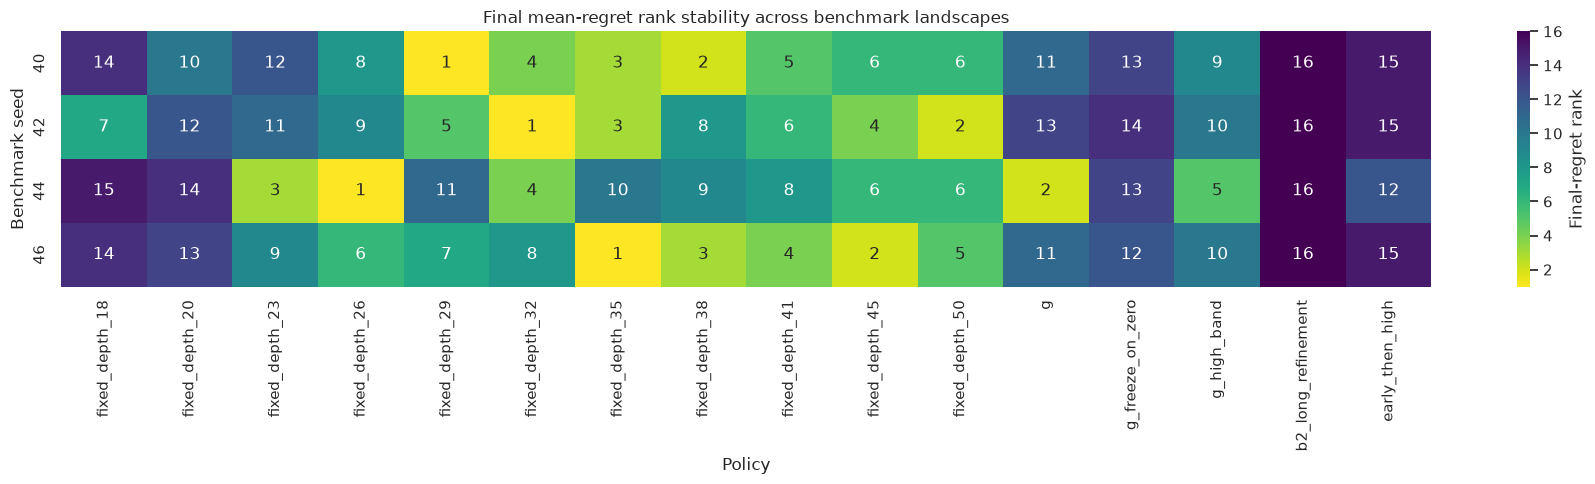

In [30]:
rank_matrix = (
    final_summary.pivot(index='benchmark_seed', columns='policy', values='rank')
    .reindex(index=BENCHMARK_SEEDS, columns=POLICIES)
)
plt.figure(figsize=(18, 5))
sns.heatmap(rank_matrix, annot=True, fmt='.0f', cmap='viridis_r', vmin=1, vmax=len(POLICIES), cbar_kws={'label': 'Final-regret rank'})
plt.title('Final mean-regret rank stability across benchmark landscapes')
plt.xlabel('Policy')
plt.ylabel('Benchmark seed')
plt.tight_layout()
plt.show()

In [31]:
anytime_runs = runs[['benchmark_seed', 'policy', 'policy_family', 'smac_seed']].copy()
anytime_runs['mean_log10_best_regret'] = np.log10(np.maximum(best_matrix, PLOT_FLOOR)).mean(axis=1)
anytime_summary = (
    anytime_runs.groupby(['benchmark_seed', 'policy', 'policy_family'], as_index=False)
    .agg(mean_log10_best_regret=('mean_log10_best_regret', 'mean'))
)
anytime_summary['anytime_rank'] = (
    anytime_summary.groupby('benchmark_seed')['mean_log10_best_regret']
    .rank(method='min', ascending=True).astype(int)
)
anytime_across = (
    anytime_summary.groupby(['policy', 'policy_family'], as_index=False)
    .agg(
        mean_anytime_rank=('anytime_rank', 'mean'),
        worst_anytime_rank=('anytime_rank', 'max'),
        mean_log10_best_regret=('mean_log10_best_regret', 'mean'),
    )
)
anytime_across['policy_order'] = anytime_across['policy'].map(POLICY_ORDER)
anytime_across = anytime_across.sort_values(['mean_anytime_rank', 'policy_order']).reset_index(drop=True)
anytime_across.insert(0, 'anytime_overall_rank', np.arange(1, len(anytime_across) + 1))
print('Anytime ranking: mean log10(best regret) over all 3,500 trials; lower is better.')
display(anytime_across.drop(columns='policy_order').style.format({
    'mean_anytime_rank': '{:.2f}', 'mean_log10_best_regret': '{:.4f}',
}))

Anytime ranking: mean log10(best regret) over all 3,500 trials; lower is better.


,anytime_overall_rank,policy,policy_family,mean_anytime_rank,worst_anytime_rank,mean_log10_best_regret
0,1,fixed_depth_29,fixed,3.75,5,4.2051
1,2,fixed_depth_26,fixed,4.00,9,4.2010
2,3,fixed_depth_32,fixed,4.50,9,4.2062
3,4,fixed_depth_45,fixed,6.75,9,4.2147
4,5,fixed_depth_50,fixed,7.00,9,4.2150
5,6,g_high_band,adaptive,7.25,13,4.2203
6,7,fixed_depth_38,fixed,7.50,13,4.2183
7,8,g,adaptive,7.50,14,4.2365
8,9,fixed_depth_41,fixed,8.00,10,4.2152
9,10,fixed_depth_23,fixed,8.75,11,4.2297


In [32]:
adaptive_terminal = runs.query("policy_family == 'adaptive'").copy()
adaptive_terminal['final_depth_set'] = adaptive_terminal['final_depth_set'].map(
    lambda values: ' + '.join(map(str, values))
)
terminal_counts = (
    adaptive_terminal.groupby(['policy', 'final_mode', 'final_depth_set'], dropna=False)
    .size().rename('runs').reset_index()
    .sort_values(['policy', 'runs'], ascending=[True, False])
)
print('Terminal adaptive depth-set stability across all 24 runs per policy')
display(terminal_counts)
runtime_summary = (
    runs.groupby(['policy', 'policy_family'], as_index=False)
    .agg(
        mean_runtime_minutes=('runtime_seconds', lambda values: values.mean() / 60),
        median_runtime_minutes=('runtime_seconds', lambda values: values.median() / 60),
        mean_surrogate_trainings=('surrogate_training_events', 'mean'),
    )
    .sort_values('mean_runtime_minutes')
)
print('Runtime and surrogate-training diagnostics')
display(runtime_summary.style.format({
    'mean_runtime_minutes': '{:.2f}', 'median_runtime_minutes': '{:.2f}',
    'mean_surrogate_trainings': '{:.1f}',
}))

Terminal adaptive depth-set stability across all 24 runs per policy


,policy,final_mode,final_depth_set,runs
6,b2_long_refinement,rotate,13 + 15 + 16,4
3,b2_long_refinement,fixed,18,3
5,b2_long_refinement,fixed,21,3
11,b2_long_refinement,rotate,7 + 12 + 16,3
2,b2_long_refinement,fixed,16,2
4,b2_long_refinement,fixed,19,2
10,b2_long_refinement,rotate,7 + 10 + 13 + 16,2
0,b2_long_refinement,fixed,10,1
1,b2_long_refinement,fixed,13,1
7,b2_long_refinement,rotate,15 + 17 + 18,1


Runtime and surrogate-training diagnostics


,policy,policy_family,mean_runtime_minutes,median_runtime_minutes,mean_surrogate_trainings
6,fixed_depth_29,fixed,23.52,24.13,361.5
14,g_freeze_on_zero,adaptive,24.89,23.62,363.9
0,b2_long_refinement,adaptive,25.70,25.33,368.5
5,fixed_depth_26,fixed,27.11,26.59,361.4
1,early_then_high,adaptive,27.39,26.28,368.2
15,g_high_band,adaptive,27.66,27.59,361.2
4,fixed_depth_23,fixed,28.86,28.98,363.5
2,fixed_depth_18,fixed,29.78,29.99,370.2
10,fixed_depth_41,fixed,30.01,30.26,360.1
8,fixed_depth_35,fixed,30.55,30.31,361.3
